# Validation and Benchmarking of European Renewable Generation Dataset

## Table of Contents

* [1 Introduction](#1-introduction)
  * [1.1 Motivation and Context](#11-motivation-and-context)
  * [1.2 Contributions](#12-contributions)
* [2 Input Data](#2-input-data)
  * [2.1 Load Generated Datasets (2015-2025)](#21-load-generated-datasets-2015-2025)
  * [2.2 Load Reported Generation (Validation Data)](#22-load-reported-generation-validation-data)
* [3 Sensitivity Analyses](#3-sensitivity-analyses)
  * [3.1 Sensitivity of Wind Generation to Turbine Model Choice](#31-sensitivity-of-wind-generation-to-turbine-model-choice)
  * [3.2 Sensitivity to Farm-Aggregation Smoothing](#32-sensitivity-to-farm-aggregation-smoothing)
  * [3.3 Sensitivity of PV Generation to Configuration Assumptions](#33-sensitivity-of-pv-generation-to-configuration-assumptions)
  * [3.4 Sensitivity to Calibration Settings](#34-sensitivity-to-calibration-settings)
* [4 Validation Results (2015-2025)](#4-validation-results-2015-2025)
  * [4.1 Evaluation Metrics](#41-evaluation-metrics)
  * [4.2 Wind Generation Validation](#42-wind-generation-validation)
  * [4.3 Solar Generation Validation](#43-solar-generation-validation)
  * [4.4 Hydropower Consistency Checks](#44-hydropower-consistency-checks)
  * [4.5 Cross-technology and Spatial Correlation](#45-cross-technology-and-spatial-correlation)
* [5 Weather-driven Variability Results (2005-2025)](#5-weather-driven-variability-results-2005-2025)
* [6 Conclusion](#6-conclusion)

## 1. Introduction
### Motivation and Context
High-resolution hourly renewable generation time series are required for energy system modeling, including adequacy assessment, storage and flexibility sizing, transmission expansion, and evaluation of weather-driven risk.

This notebook implements the validation and benchmarking of the dataset defined in the accompanying article. It covers:
1. **Sensitivity Analyses**: Quantifying the robustness of the dataset to key modeling assumptions and heuristics.
2. **Validation Results**: Comparing the calibrated historical generation dataset (2015–2025) against reported generation (ENTSO-E Transparency Platform).
3. **Weather-driven Variability**: Analyzing the fixed-layout dataset (2005–2025) to isolate weather effects from capacity expansion.

### Contributions
- Validate country-level aggregated wind and solar PV generation.
- Validate bidding-zone level generation for Norway, Sweden, and Denmark.
- Assess sensitivity to turbine model choice, spatial smoothing, and PV configuration assumptions.

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import dask
import importlib
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

#parent directory to path to import functions
sys.path.append(os.path.abspath('..'))
import functions

env_bin = os.path.join(sys.prefix, "bin")
if env_bin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

# Add TinyTeX to PATH for LaTeX rendering (text.usetex: True)
tinytex_bin = os.path.expanduser("~/.TinyTeX/bin/x86_64-linux")
if os.path.isdir(tinytex_bin) and tinytex_bin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = tinytex_bin + os.pathsep + os.environ.get("PATH", "")

#parent directory to path to import functions
sys.path.append(os.path.abspath('..'))

style_path = Path('custom_latex_style.mplstyle')
if style_path.exists():
    print(f"Using custom Matplotlib style from: {style_path}")
    plt.style.use(str(style_path))

Using custom Matplotlib style from: custom_latex_style.mplstyle


In [2]:
OUT_DIR = Path("/Data/gfi/vindenergi/nab015/figures/validation")
if not OUT_DIR.exists():
    OUT_DIR.mkdir(parents=True)

## 2. Input Data
### 2.1 Load Generated Datasets (2015-2025)
Load the aggregated wind and solar power generation datasets. These files are produced by the generation scripts (`solar_production_aggregated_generation.py`, etc.).

In [3]:
MONTHS = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
YEAR = "2025"

In [4]:
# base_agg = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/country-aggregated-production/{YEAR}")
# base_farm = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/per-farm-production/{YEAR}")
base_agg = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/uncalibrated/country-aggregated-production/{YEAR}") #uncalibrated
base_farm = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/uncalibrated/per-farm-production/{YEAR}") #uncalibrated
agg_files = [
    base_agg / f"{m}_{YEAR}_pv_wind_country_timeseries.nc"
    for m in MONTHS
    if (base_agg / f"{m}_{YEAR}_pv_wind_country_timeseries.nc").exists()
 ]
agg_files = sorted(agg_files)

farm_files = [
    base_farm / f"{m}_{YEAR}_pv_wind_grid.nc"
    for m in MONTHS
    if (base_farm / f"{m}_{YEAR}_pv_wind_grid.nc").exists()
 ]
farm_files = sorted(farm_files)

if not agg_files:
    raise FileNotFoundError(f"No aggregated files found under {base_agg}")
if not farm_files:
    raise FileNotFoundError(f"No per-farm files found under {base_farm}")

def _select_perfarm_vars(ds):
    keep = [v for v in ["wind_offshore_mw", "wind_onshore_mw", "pv_mw"] if v in ds.data_vars]
    return ds[keep] if keep else ds

print(f"Loading {len(agg_files)} aggregated monthly files...")
ds = xr.open_mfdataset(
    agg_files,
    combine="nested",
    concat_dim="time",
    parallel=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    engine="h5netcdf",
    chunks={"time": 168},
).sortby("time")

print(f"Loading {len(farm_files)} per-farm monthly files (lazy, chunked)...")
ds_perfarm = xr.open_mfdataset(
    farm_files,
    combine="nested",
    concat_dim="time",
    parallel=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    engine="h5netcdf",
    preprocess=_select_perfarm_vars,
    chunks={"time": 24},
).sortby("time")

print("Combined datasets loaded successfully.")

Loading 12 aggregated monthly files...


/home/nab015/.conda/envs/energy_mod/lib/python3.10/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 168. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)


Loading 12 per-farm monthly files (lazy, chunked)...


/home/nab015/.conda/envs/energy_mod/lib/python3.10/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 24. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)


Combined datasets loaded successfully.


In [5]:
# Quick test: load only July 2024
first_day_start = f"{YEAR}-07-01"
first_day_end = f"{YEAR}-07-07T23:59:59"
first_day_file = base_farm / f"07_{YEAR}_pv_wind_grid.nc"
ds_perfarm_day = xr.open_dataset(
    first_day_file,
    engine="h5netcdf",
    chunks={"time": 24},
).sel(time=slice(first_day_start, first_day_end))
ds_perfarm_day

<xarray.Dataset> Size: 3GB
Dimensions:                  (time: 167, y: 1069, x: 1069)
Coordinates:
  * time                     (time) datetime64[ns] 1kB 2025-07-01T01:00:00 .....
  * y                        (y) int64 9kB 0 1 2 3 4 ... 1065 1066 1067 1068
  * x                        (x) int64 9kB 0 1 2 3 4 ... 1065 1066 1067 1068
    latitude                 (y, x) float64 9MB dask.array<chunksize=(1069, 1069), meta=np.ndarray>
    longitude                (y, x) float64 9MB dask.array<chunksize=(1069, 1069), meta=np.ndarray>
Data variables:
    wind_power_mw_onshore    (time, y, x) float32 763MB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    wind_power_mw_offshore   (time, y, x) float32 763MB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    pv_power_mw              (time, y, x) float32 763MB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    pv_power_mw_distributed  (time, y, x) float32 763MB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>

In [6]:
ds

<xarray.Dataset> Size: 13MB
Dimensions:             (time: 8760, area: 47)
Coordinates:
  * time                (time) datetime64[ns] 70kB 2025-01-01T01:00:00 ... 20...
  * area                (area) <U21 4kB 'Austria (AT)' ... 'Åland Islands (ÅL)'
Data variables:
    pv_power_mw         (time, area) float64 3MB dask.array<chunksize=(168, 12), meta=np.ndarray>
    pv_power_mw_2025    (time, area) float64 3MB dask.array<chunksize=(168, 12), meta=np.ndarray>
    wind_power_mw       (time, area) float64 3MB dask.array<chunksize=(168, 12), meta=np.ndarray>
    wind_power_mw_2025  (time, area) float64 3MB dask.array<chunksize=(168, 12), meta=np.ndarray>
Attributes:
    year:          2025
    month_number:  01
    month_name:    jan
    note:          as-built calibrated factor applied to both as-built and 20...

In [7]:
ds_perfarm

<xarray.Dataset> Size: 160GB
Dimensions:                  (time: 8760, y: 1069, x: 1069)
Coordinates:
  * time                     (time) datetime64[ns] 70kB 2025-01-01T01:00:00 ....
  * y                        (y) int64 9kB 0 1 2 3 4 ... 1065 1066 1067 1068
  * x                        (x) int64 9kB 0 1 2 3 4 ... 1065 1066 1067 1068
    latitude                 (y, x) float64 9MB dask.array<chunksize=(1069, 1069), meta=np.ndarray>
    longitude                (y, x) float64 9MB dask.array<chunksize=(1069, 1069), meta=np.ndarray>
Data variables:
    wind_power_mw_onshore    (time, y, x) float32 40GB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    wind_power_mw_offshore   (time, y, x) float32 40GB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    pv_power_mw              (time, y, x) float32 40GB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>
    pv_power_mw_distributed  (time, y, x) float32 40GB dask.array<chunksize=(24, 34, 67), meta=np.ndarray>

### 2.2 Load Reported Generation (Validation Data)
Load the actual generation data from ENTSO-E or national TSOs for validation.

In [8]:
actual_base = Path(f"/Data/gfi/vindenergi/nab015/Actual_Generation/AggregatedGenerationPerType/{YEAR}")
actual_files = [
    actual_base / f"{YEAR}_{m}_AggregatedGenerationPerType_16.1.B_C_r3.csv"
    for m in MONTHS
    if (actual_base / f"{YEAR}_{m}_AggregatedGenerationPerType_16.1.B_C_r3.csv").exists()
 ]
actual_files = sorted(actual_files)

if not actual_files:
    raise FileNotFoundError(f"No actual generation files found under {actual_base}")

usecols = ["DateTime(UTC)", "MTU", "AreaDisplayName", "AreaCode", "ProductionType", "ActualGenerationOutput[MW]"]
def _read_actual(path):
    df = pd.read_csv(path, sep="\t", usecols=lambda c: c in usecols, low_memory=False)
    return df

print(f"Loading {len(actual_files)} actual generation files...")
df_actual = pd.concat((_read_actual(p) for p in actual_files), ignore_index=True)

print("Actual generation data loaded (yearly combined).")

Loading 12 actual generation files...
Actual generation data loaded (yearly combined).


### 2.3 Map of European renewable production
Plotting the high-resolution grid (5.5kmx5.5km) with total wind + PV power generation 

In [9]:
offshore_production = ds_perfarm_day['wind_power_mw_offshore'].sum(dim='time')
onshore_production = ds_perfarm_day['wind_power_mw_onshore'].sum(dim='time')
pv_production = ds_perfarm_day['pv_power_mw'].sum(dim='time')
pv_distributed = ds_perfarm_day['pv_power_mw_distributed'].sum(dim='time')
onshore_2d = onshore_production.squeeze()
offshore_2d = offshore_production.squeeze()
pv_2d = pv_production.squeeze()
pv_distributed_2d = pv_distributed.squeeze()
if onshore_2d.dims != ('y', 'x'):
    onshore_2d = onshore_2d.transpose('y', 'x')
if offshore_2d.dims != ('y', 'x'):
    offshore_2d = offshore_2d.transpose('y', 'x')
if pv_2d.dims != ('y', 'x'):
    pv_2d = pv_2d.transpose('y', 'x')
if pv_distributed_2d.dims != ('y', 'x'):
    pv_distributed_2d = pv_distributed_2d.transpose('y', 'x')

total_production = (
    onshore_2d.fillna(0)
    + offshore_2d.fillna(0)
    + pv_2d.fillna(0)
    + pv_distributed_2d.fillna(0)
)


In [ ]:
#gaussian Smoothing
sigma = 0.5
power_values_smoothed = gaussian_filter(total_production.values, sigma=sigma)
power_2d_smoothed = total_production.copy(data=power_values_smoothed)
power_2d_masked = power_2d_smoothed.where(power_2d_smoothed > 0)

In [11]:
# 3. Create Custom Colormap
LAND_COLOR = "#9fa1a5"
colors = ["#ffeda0", "#feb24c", "#fd8d3c", "#f03b20", "#e31a1c", "#980043", "#7a0177", "#4a1486", "#253494"]
cmap_custom = mcolors.LinearSegmentedColormap.from_list("land_blend_red_blue", colors, N=256)
cmap_custom.set_bad(LAND_COLOR)
cmap_custom.set_under(LAND_COLOR)

plt.figure(figsize=(12, 16))
#plt.title(f'Total monthly wind + solar production in Europe ({MONTH}-{YEAR})', fontsize=16)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-15, 42, 35, 72], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="#c7d9f2", zorder=0)
ax.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, zorder=2)

pcm = power_2d_masked.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='longitude', 
    y='latitude',
    cmap=cmap_custom,
    add_colorbar=False,
    rasterized=True,
    norm=mcolors.LogNorm(vmin=1, vmax=1.5e4)
 )

cbar = plt.colorbar(pcm, orientation='horizontal', pad=0.05, fraction=0.04, aspect=40)
cbar.set_label('Total Energy Production (MWh)', fontsize=12)
cbar.ax.tick_params(labelsize=10)
# plt.title(f'Total monthly wind + solar production in Europe ({month_number}-{YEAR})')
out = OUT_DIR / f'total_energy_production_map_{YEAR}.pdf'
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

In [ ]:
colors = ['#ffffe5', '#fff7bc', '#fee391', '#fec44f', '#fe9929', '#ec7014', '#cc4c02', '#993404', '#662506']
cmap_name = "custom_YlOrBr"

# ───────────────────────────────────────────────────────────────────────────

cmap_custom = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=256)
DE_EXTENT = [5.5, 15.5, 45.0, 55.5]  # Original tight box around Germany
DE_EXTENT = [5.0, 16.0, 53.0, 59.0]

# Clip to Germany bounding box (include 1-cell padding)
lon_2d = power_2d_masked["longitude"].values
lat_2d = power_2d_masked["latitude"].values
mask_de = (
    (lon_2d >= DE_EXTENT[0]) & (lon_2d <= DE_EXTENT[1]) &
    (lat_2d >= DE_EXTENT[2]) & (lat_2d <= DE_EXTENT[3])
)
rows_de = np.where(mask_de.any(axis=1))[0]
cols_de = np.where(mask_de.any(axis=0))[0]
r0 = max(rows_de[0] - 1, 0);  r1 = min(rows_de[-1] + 2, power_2d_masked.shape[0])
c0 = max(cols_de[0] - 1, 0);  c1 = min(cols_de[-1] + 2, power_2d_masked.shape[1])
power_de = power_2d_masked.isel(y=slice(r0, r1), x=slice(c0, c1))

# Colormap that maps NaN (empty cells) → white, with black cell borders
cmap_de = mcolors.LinearSegmentedColormap.from_list("de_cmap", colors, N=256)
cmap_de.set_bad("white")
cmap_de.set_under("white")

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(DE_EXTENT, crs=ccrs.PlateCarree())
ax.set_facecolor("white")

# White land background so empty cells blend seamlessly
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#c7d9f2", zorder=0)

# pcolormesh: black edges on every cell (including empty/NaN ones → white fill)
pcm_de = power_de.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    cmap=cmap_de,
    add_colorbar=False,
    norm=mcolors.LogNorm(vmin=1, vmax=1.0e5),
    edgecolors="grey",
    linewidths=0.06,
    zorder=1,
    rasterized=True
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle="-", linewidth=0.95, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.30, linestyle="--", color="grey", alpha=0.5, zorder=3)
gl.top_labels = False
gl.right_labels = False

# Adjust colorbar placement to match the image
cbar_de = plt.colorbar(pcm_de, ax=ax, orientation="horizontal", pad=0.05, fraction=0.04, aspect=40)
cbar_de.set_label("Total Energy Production (MWh)", fontsize=14)
cbar_de.ax.tick_params(labelsize=12)

# ax.set_title(f"Germany – Total Energy Production (July 2024)", fontsize=13)

out_de = OUT_DIR / f"total_energy_production_north_europe_{YEAR}.pdf"
plt.savefig(out_de, dpi=300, bbox_inches="tight", pad_inches=0)
# plt.show()
plt.close()
print(f"Saved: {out_de}")


Saved: /Data/gfi/vindenergi/nab015/figures/validation/total_energy_production_north_europe_2025.pdf


In [28]:
NORTH_EXTENT = [-15, 42, 35, 72]
NORTH_EXTENT = [5.0, 16.0, 53.0, 59.0]
NORTH_EXTENT = [5.5, 15.0, 53.0, 58.0]

panels = [
    ('(a) Wind onshore',   onshore_2d,        ['#f7fbff','#c6dbef','#6baed6','#2171b5','#08306b']),
    ('(b) Wind offshore',  offshore_2d,       ['#f7fbff','#c6dbef','#6baed6','#08519c','#03244d']),
    ('(c) PV utility',     pv_2d,             ['#ffffe5','#fff7bc','#fec44f','#ec7014','#662506']),
    ('(d) PV distributed', pv_distributed_2d, ['#ffffe5','#fff7bc','#fec44f','#d94701','#7f2704']),
]

fig, axes = plt.subplots(
    2, 2, figsize=(12, 9.5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.05, 'wspace': 0.07}
)

for idx, (ax, (title, data_2d, pal)) in enumerate(zip(axes.flat, panels)):
    col = idx % 2
    row = idx // 2

    cmap = mcolors.LinearSegmentedColormap.from_list(title, pal, N=256)
    cmap.set_bad("white")
    cmap.set_under("white")
    masked = data_2d.where(data_2d > 0)

    ax.set_extent(NORTH_EXTENT, crs=ccrs.PlateCarree())
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND,  facecolor="white",   zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#c7d9f2", zorder=0)

    pcm = masked.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        x='longitude', y='latitude',
        cmap=cmap,
        add_colorbar=False,
        norm=mcolors.LogNorm(vmin=1, vmax=1.5e4),
        rasterized=True,
        zorder=1,
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
    ax.add_feature(cfeature.BORDERS,   linestyle='-', linewidth=0.7, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.25, linestyle='--', color='grey', alpha=0.5, zorder=3)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (col == 0)
    # gl.bottom_labels = (row == 1)

    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05, aspect=30)
    cbar.set_label('Total Energy Production (MWh)', fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=6)

out = OUT_DIR / f'technology_maps_2x2_{YEAR}.pdf'
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0.02)
out_png = OUT_DIR / f'technology_maps_2x2_{YEAR}.png'
plt.savefig(out_png, dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.close()
print(f"Saved: {out}")
print(f"Saved: {out_png}")

Saved: /Data/gfi/vindenergi/nab015/figures/validation/technology_maps_2x2_2025.pdf
Saved: /Data/gfi/vindenergi/nab015/figures/validation/technology_maps_2x2_2025.png


## 4. Validation Results (2015-2025)
### 4.1 Evaluation Metrics
Calculate NMAE, NRMSE, Bias, and $R^2$ for each country and bidding zone.

In [9]:
# Installed capacity from active tracker installations (as-built up to YEAR)
from scripts.weather_energy_monthly import PVCalculator, WindCalculator, ZONES, countries_tracker, countries_codes

prod_year = int(YEAR)
pv_calc = PVCalculator(n_jobs=1)
wind_calc = WindCalculator()

def _zone_filter(df, area_code):
    """Replicate zone split logic used in weather_energy_monthly/validation code."""
    if df.empty or area_code not in ZONES:
        return df

    out = df.copy()
    if area_code.startswith('DK'):
        lon_vals = pd.to_numeric(out['Longitude'], errors='coerce')
        if area_code == 'DK1':
            out = out[lon_vals < 10.5]
        elif area_code == 'DK2':
            out = out[lon_vals >= 10.5]
    elif area_code.startswith('NO'):
        lat_vals = pd.to_numeric(out['Latitude'], errors='coerce')
        lon_vals = pd.to_numeric(out['Longitude'], errors='coerce')
        if area_code == 'NO1':
            out = out[(lat_vals < 60.5) & (lon_vals > 9.5)]
        elif area_code == 'NO2':
            out = out[(lat_vals < 60.5) & (lon_vals <= 9.5)]
        elif area_code == 'NO3':
            out = out[(lat_vals >= 60.5) & (lat_vals < 64.5)]
        elif area_code == 'NO4':
            out = out[lat_vals >= 64.5]
        elif area_code == 'NO5':
            out = out[(lat_vals >= 60.5) & (lon_vals < 7.0)]
    elif area_code.startswith('SE'):
        lat_vals = pd.to_numeric(out['Latitude'], errors='coerce')
        if area_code == 'SE1':
            out = out[lat_vals >= 64.5]
        elif area_code == 'SE2':
            out = out[(lat_vals >= 60.5) & (lat_vals < 64.5)]
        elif area_code == 'SE3':
            out = out[(lat_vals >= 58.5) & (lat_vals < 60.5)]
        elif area_code == 'SE4':
            out = out[lat_vals < 58.5]
    return out

def _sum_capacity(df, cap_col='Capacity (MW)'):
    return pd.to_numeric(df.get(cap_col, pd.Series(dtype=float)), errors='coerce').fillna(0.0).sum()

# Cache active-status sets per tracker country to avoid repeated function calls.
unique_tracker_countries = sorted(
    set(c for c in pd.concat([wind_calc.df['Country/Area'], pv_calc.df_main['Country/Area']]).dropna().astype(str).unique())
)
active_wind_status_by_country = {
    c: set(functions.operating_farms(c, 'wind')) for c in unique_tracker_countries
}
active_solar_status_by_country = {
    c: set(functions.operating_farms(c, 'solar')) for c in unique_tracker_countries
}

installed_capacity_wind_mw = {}
installed_capacity_pv_mw = {}
rows = []

for country_tracker_name, area_code in zip(countries_tracker, countries_codes):
    op_wind = active_wind_status_by_country.get(country_tracker_name, set())
    op_solar = active_solar_status_by_country.get(country_tracker_name, set())

    # Wind (as-built active capacity)
    df_w = wind_calc.df[wind_calc.df['Country/Area'] == country_tracker_name].copy()
    if not df_w.empty:
        df_w = _zone_filter(df_w, area_code)
        df_w = df_w[df_w['Status'].isin(op_wind)].copy()
        start_year_w = pd.to_numeric(df_w['Start year'], errors='coerce')
        ref_w = float(getattr(wind_calc, 'ref_startyear', prod_year))
        model_year_w = np.where(np.isfinite(start_year_w), np.floor(start_year_w), ref_w).astype(int)
        df_w = df_w[(model_year_w >= 1800) & (model_year_w <= prod_year)]
    wind_cap = _sum_capacity(df_w)

    # Solar (utility tracker + distributed tracker)
    df_s_all = pv_calc.df_main[pv_calc.df_main['Country/Area'] == country_tracker_name].copy()
    if not df_s_all.empty:
        df_s_all = df_s_all[df_s_all['Status'].isin(op_solar)].copy()
        s_years = pd.to_numeric(df_s_all['Start year'], errors='coerce')
        df_s_all = df_s_all[np.isfinite(s_years) & (s_years <= prod_year)].copy()

    df_s = _zone_filter(df_s_all, area_code)

    df_dist_country = pv_calc.df_distributed[pv_calc.df_distributed['Country/Area'] == country_tracker_name].copy()
    if not df_dist_country.empty:
        if 'Status' in df_dist_country.columns:
            df_dist_country = df_dist_country[df_dist_country['Status'].isin(op_solar)].copy()
        if 'Year' in df_dist_country.columns:
            dist_years = pd.to_numeric(df_dist_country['Year'], errors='coerce')
            df_dist_country = df_dist_country[np.isfinite(dist_years) & (dist_years <= prod_year)].copy()
    distributed_capacity = _sum_capacity(df_dist_country)

    utility_capacity = _sum_capacity(df_s)
    utility_capacity_country = _sum_capacity(df_s_all)
    distributed_capacity_effective = float(distributed_capacity)

    # Pro-rate distributed PV when splitting countries into bidding zones.
    if area_code in ZONES and utility_capacity_country > 0 and distributed_capacity > 0:
        distributed_capacity_effective = float(distributed_capacity * (utility_capacity / utility_capacity_country))

    solar_cap = utility_capacity + distributed_capacity_effective

    installed_capacity_wind_mw[area_code] = float(wind_cap)
    installed_capacity_pv_mw[area_code] = float(solar_cap)

    rows.append({
        'Area': area_code,
        'Wind_Capacity_MW': float(wind_cap),
        'Solar_Capacity_MW': float(solar_cap),
        'Installed_Capacity_MW': float(wind_cap + solar_cap),
    })

installed_capacity_total_mw = {
    area: installed_capacity_wind_mw.get(area, 0.0) + installed_capacity_pv_mw.get(area, 0.0)
    for area in installed_capacity_wind_mw.keys()
}

installed_capacity_df = pd.DataFrame(rows).set_index('Area').sort_index()

# Global totals from full trackers (active + as-built to YEAR).
wind_global = wind_calc.df.copy()
wind_global = wind_global[
    wind_global.apply(
        lambda r: r['Status'] in active_wind_status_by_country.get(str(r['Country/Area']), set()),
        axis=1,
    )
].copy()
wind_start = pd.to_numeric(wind_global['Start year'], errors='coerce')
ref_global_w = float(getattr(wind_calc, 'ref_startyear', prod_year))
wind_model_year = np.where(np.isfinite(wind_start), np.floor(wind_start), ref_global_w).astype(int)
wind_global = wind_global[(wind_model_year >= 1800) & (wind_model_year <= prod_year)]
wind_global_installed_capacity_mw = _sum_capacity(wind_global) 
pv_main_global = pv_calc.df_main.copy()
pv_main_global = pv_main_global[
    pv_main_global.apply(
        lambda r: r['Status'] in active_solar_status_by_country.get(str(r['Country/Area']), set()),
        axis=1,
    )
].copy()
pv_start = pd.to_numeric(pv_main_global['Start year'], errors='coerce')
pv_main_global = pv_main_global[np.isfinite(pv_start) & (pv_start <= prod_year)]

pv_dist_global = pv_calc.df_distributed.copy()
if 'Status' in pv_dist_global.columns:
    pv_dist_global = pv_dist_global[
        pv_dist_global.apply(
            lambda r: r['Status'] in active_solar_status_by_country.get(str(r['Country/Area']), set()),
            axis=1,
        )
    ].copy()
if 'Year' in pv_dist_global.columns:
    pv_dist_year = pd.to_numeric(pv_dist_global['Year'], errors='coerce')
    pv_dist_global = pv_dist_global[np.isfinite(pv_dist_year) & (pv_dist_year <= prod_year)]

solar_global_installed_capacity_mw = (_sum_capacity(pv_main_global) + _sum_capacity(pv_dist_global))
global_installed_capacity_mw = wind_global_installed_capacity_mw + solar_global_installed_capacity_mw

print(f"Installed capacity by area calculated for {len(installed_capacity_df)} areas.")
print(f"Global wind installed capacity (active, as-built): {wind_global_installed_capacity_mw:,.1f} MW")
print(f"Global solar installed capacity (active, as-built): {solar_global_installed_capacity_mw:,.1f} MW")
print(f"Global total installed capacity (active, as-built): {global_installed_capacity_mw:,.1f} MW")
installed_capacity_df.head()

Installed capacity by area calculated for 47 areas.
Global wind installed capacity (active, as-built): 379,143.2 MW
Global solar installed capacity (active, as-built): 340,357.8 MW
Global total installed capacity (active, as-built): 719,501.0 MW


,Wind_Capacity_MW,Solar_Capacity_MW,Installed_Capacity_MW
Area,,,
Albania (AL),0.0,0.0,0.0
Austria (AT),3255.0,8100.4,11355.4
Belgium (BE),7218.0,905.1,8123.1
Bosnia and Herz. (BA),244.0,539.5,783.5
Bulgaria (BG),608.0,3529.0,4137.0


In [10]:
# Total number of operating farms (wind/solar) for countries considered
required = [
    "wind_global",
    "pv_main_global",
    "unique_tracker_countries",
    "active_wind_status_by_country",
    "active_solar_status_by_country",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run the tracker setup cell first; missing variables: {missing}")

countries_considered = set(map(str, unique_tracker_countries))

wind_operating_farms = wind_global.loc[
    wind_global["Country/Area"].astype(str).isin(countries_considered)
    & wind_global.apply(
        lambda r: r["Status"] in active_wind_status_by_country.get(str(r["Country/Area"]), set()),
        axis=1,
    )
]

solar_operating_farms = pv_main_global.loc[
    pv_main_global["Country/Area"].astype(str).isin(countries_considered)
    & pv_main_global.apply(
        lambda r: r["Status"] in active_solar_status_by_country.get(str(r["Country/Area"]), set()),
        axis=1,
    )
]

print(f"Total operating wind farms (countries considered): {len(wind_operating_farms):,}")
print(f"Total operating solar farms (countries considered): {len(solar_operating_farms):,}")

Total operating wind farms (countries considered): 9,183
Total operating solar farms (countries considered): 22,035


In [11]:
def fractional_bias(pred, obs):
    """Calculate fractional bias between predicted and observed values."""
    pred = np.asarray(pred)
    obs = np.asarray(obs)
    mask = (pred + obs) > 0
    if not np.any(mask):
        return np.nan
    return 2 * sum((pred[mask] - obs[mask])) / sum(pred[mask] + obs[mask])

In [12]:
def calculate_metrics(simulated_ts, actual_ts, installed_capacity_mw):
    common_idx = simulated_ts.index.intersection(actual_ts.index)
    if len(common_idx) == 0:
        return None
    
    sim = simulated_ts.loc[common_idx]
    act = actual_ts.loc[common_idx]
    
    bias = fractional_bias(sim, act)
    mae = mean_absolute_error(act, sim)
    rmse = np.sqrt(mean_squared_error(act, sim))
    r, _ = pearsonr(act, sim)
    
    if installed_capacity_mw is None or installed_capacity_mw <= 0:
        nmae = np.nan
        nrmse = np.nan
    else:
        nmae = mae / installed_capacity_mw
        nrmse = rmse / installed_capacity_mw
    
    return {
        'Bias': bias,
        'NMAE': nmae,
        'NRMSE': nrmse,
        'R2': r
    }

### 4.2 Wind generation validation

In [13]:
def tracker_capacity_for_area(area_label, tech, simulated_ts=None):
    if tech == 'wind':
        cap_map = installed_capacity_wind_mw
    elif tech == 'solar':
        cap_map = installed_capacity_pv_mw
    else:
        cap_map = installed_capacity_total_mw

    cap = cap_map.get(area_label, np.nan)
    if (not np.isfinite(cap) or cap <= 0) and isinstance(area_label, str) and '(' in area_label and ')' in area_label:
        short_code = area_label.split('(')[-1].strip(')')
        cap = cap_map.get(short_code, np.nan)

    if (not np.isfinite(cap) or cap <= 0) and simulated_ts is not None:
        cap = pd.to_numeric(simulated_ts, errors='coerce').max()

    return float(cap) if np.isfinite(cap) else np.nan

In [14]:
country_list = ds['area']
country_names = country_list.values.tolist()
metrics_df = pd.DataFrame(index=country_names, columns=['Bias', 'NMAE', 'NRMSE', 'R2'])

for country in tqdm(country_names, desc="Calculating metrics for countries", unit="country"):
    simulated = ds['wind_power_mw'].sel(area=country).to_pandas()
    actual = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Wind', case=False, na=False))
    ].copy()

    actual = actual.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()
    actual.index = pd.to_datetime(actual.index)
    simulated.index = pd.to_datetime(simulated.index)

    installed_capacity_mw = tracker_capacity_for_area(country, tech='wind', simulated_ts=simulated)
    metrics = calculate_metrics(simulated, actual, installed_capacity_mw)
    if metrics is not None:
        metrics_df.loc[country] = metrics

metrics_df

Calculating metrics for countries:   0%|          | 0/47 [00:00<?, ?country/s]

Calculating metrics for countries:  34%|███▍      | 16/47 [01:52<03:36,  6.99s/country]/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
Calculating metrics for countries:  53%|█████▎    | 25/47 [02:55<02:34,  7.03s/country]/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
Calculating metrics for countries:  89%|████████▉ | 42/47 [04:50<00:34,  6.88s/country]/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
Calculating metrics for countries:  91%|█████████▏| 43/47 [04:57<00:27,  6.85s/country]/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)


,Bias,NMAE,NRMSE,R2
Austria (AT),0.027094,0.095033,0.130566,0.887312
Albania (AL),NaN,NaN,NaN,NaN
Bosnia and Herz. (BA),1.205014,0.251981,0.348407,0.746
Belgium (BE),0.380864,0.104311,0.128238,0.864183
Bulgaria (BG),0.268508,0.1068,0.145484,0.866487
Switzerland (CH),-0.211003,0.121779,0.170852,0.783467
Cyprus (CY),-0.009643,0.081859,0.121835,0.614791
Czech Republic (CZ),-0.546195,0.206428,0.274739,0.866622
Germany (DE),0.295284,0.10007,0.126818,0.916573
DK1,0.039647,0.035119,0.046517,0.888063


In [90]:
def calc_net_generation_cap(filename, year=2024):
    """Load ENTSO-E installed capacity and aggregate by country/technology.

    Args:
        filename: Path to ENTSO-E InstalledGenerationCapacityAggregated CSV file.
        year: Year to extract (default 2024, matching tracker operating capacity timing).
    """
    net = pd.read_csv(
        filename,
        sep="\t",
        usecols=["AreaMapCode", "Year", "ProductionType", "AggregatedInstalledCapacity[MW]"],
        low_memory=False,
    ).copy()

    net["AreaMapCode"] = net["AreaMapCode"].astype(str).str.strip()
    net["Year"] = pd.to_numeric(net["Year"], errors="coerce")
    net["ProductionType"] = net["ProductionType"].astype(str).str.strip()
    net["AggregatedInstalledCapacity[MW]"] = pd.to_numeric(
        net["AggregatedInstalledCapacity[MW]"], errors="coerce"
    ).fillna(0.0)

    net = net[
        (net["Year"] == int(year))
        & (net["ProductionType"].isin(["Wind Onshore", "Wind Offshore", "Solar"]))
    ]

    wide = (
        net.groupby(["AreaMapCode", "Year", "ProductionType"], as_index=False)[
            "AggregatedInstalledCapacity[MW]"
        ]
        .sum()
        .pivot(index=["AreaMapCode", "Year"], columns="ProductionType", values="AggregatedInstalledCapacity[MW]")
        .fillna(0.0)
    )

    for c in ["Wind Onshore", "Wind Offshore", "Solar"]:
        if c not in wide.columns:
            wide[c] = 0.0

    df = wide.reset_index().rename(columns={"AreaMapCode": "Country"})
    df["NetGenerationCapacity_MW_wind"] = df["Wind Onshore"] + df["Wind Offshore"]
    df["NetGenerationCapacity_MW_solar"] = df["Solar"]

    return df[["Country", "Year", "NetGenerationCapacity_MW_wind", "NetGenerationCapacity_MW_solar"]].sort_values(
        ["Country", "Year"]
    ).reset_index(drop=True)


def calc_net_generation_cap_legacy(filename, year=2024):
    """Load legacy net_generation_capacity_2024.csv and map to standard capacity schema.

    Returns columns compatible with calc_net_generation_cap():
    Country, Year, NetGenerationCapacity_MW_wind, NetGenerationCapacity_MW_solar
    """
    legacy = pd.read_csv(filename, sep=None, engine="python").copy()

    required = {"Category", "Country", "Year", "ProvidedValue"}
    missing = sorted(required - set(legacy.columns))
    if missing:
        raise ValueError(
            f"Legacy file missing required columns: {missing}. "
            f"Expected columns include {sorted(required)}"
        )

    legacy["Country"] = legacy["Country"].astype(str).str.strip()
    legacy["Category"] = legacy["Category"].astype(str).str.strip()
    legacy["Year"] = pd.to_numeric(legacy["Year"], errors="coerce")
    legacy["ProvidedValue"] = pd.to_numeric(legacy["ProvidedValue"], errors="coerce").fillna(0.0)

    legacy = legacy[legacy["Year"] == int(year)]

    wind_mask = legacy["Category"].str.contains("wind", case=False, na=False)
    solar_mask = legacy["Category"].str.contains("solar|pv", case=False, na=False)

    grouped = (
        legacy.assign(
            NetGenerationCapacity_MW_wind=np.where(wind_mask, legacy["ProvidedValue"], 0.0),
            NetGenerationCapacity_MW_solar=np.where(solar_mask, legacy["ProvidedValue"], 0.0),
        )
        .groupby(["Country", "Year"], as_index=False)[
            ["NetGenerationCapacity_MW_wind", "NetGenerationCapacity_MW_solar"]
        ]
        .sum()
    )

    return grouped.sort_values(["Country", "Year"]).reset_index(drop=True)


def compare_net_generation_capacity_2024_csv(reference_df, legacy_file, year=2024):
    """Compare ENTSO-E capacity table with legacy net_generation_capacity_2024.csv.

    Expected legacy columns are: Category, Country, Year, ProvidedValue.
    Returns a country-level comparison table with wind/solar totals and deltas.
    """
    legacy_df = calc_net_generation_cap_legacy(legacy_file, year=year)
    legacy_grouped = legacy_df.rename(
        columns={
            "NetGenerationCapacity_MW_wind": "legacy_wind",
            "NetGenerationCapacity_MW_solar": "legacy_solar",
        }
    ).copy()
    legacy_grouped["legacy_total"] = legacy_grouped["legacy_wind"] + legacy_grouped["legacy_solar"]
    legacy_grouped = legacy_grouped[["Country", "legacy_wind", "legacy_solar", "legacy_total"]]

    ref = reference_df.copy()
    ref["Country"] = ref["Country"].astype(str).str.strip()
    ref = ref[["Country", "NetGenerationCapacity_MW_wind", "NetGenerationCapacity_MW_solar"]].copy()
    ref = ref.rename(
        columns={
            "NetGenerationCapacity_MW_wind": "entsoe_wind",
            "NetGenerationCapacity_MW_solar": "entsoe_solar",
        }
    )
    ref["entsoe_total"] = ref["entsoe_wind"] + ref["entsoe_solar"]

    out = ref.merge(legacy_grouped, on="Country", how="outer").fillna(0.0)
    out["delta_total"] = out["legacy_total"] - out["entsoe_total"]
    out["delta_wind"] = out["legacy_wind"] - out["entsoe_wind"]
    out["delta_solar"] = out["legacy_solar"] - out["entsoe_solar"]

    return out.sort_values("Country").reset_index(drop=True)


In [116]:
base_path = Path(globals().get("REPO_ROOT", Path.cwd()))

# Toggle source for actual installed capacity used in capacity-factor calculations.
# Options: "entsoe" (recommended) or "legacy_2024_csv"
ACTUAL_CAPACITY_SOURCE = "entsoe"
CAPACITY_YEAR = 2024

# ENTSO-E aggregated installed capacity (reference).
entso_cap_file = base_path / "InstalledGenerationCapacityAggregated_14.1.A_r3.csv"
entso_net_gen_df = calc_net_generation_cap(entso_cap_file, year=CAPACITY_YEAR)

# Legacy capacity table (optional source and comparison).
legacy_cap_file = Path("/Data/gfi/vindenergi/nab015/Actual_Generation/net_generation_capacity_2024.csv")
legacy_net_gen_df = pd.DataFrame()
if legacy_cap_file.exists():
    legacy_net_gen_df = calc_net_generation_cap_legacy(legacy_cap_file, year=CAPACITY_YEAR)
    net_gen_legacy_comparison_df = compare_net_generation_capacity_2024_csv(
        entso_net_gen_df,
        legacy_cap_file,
        year=CAPACITY_YEAR,
    )
    # Show the largest absolute mismatches first.
    net_gen_legacy_comparison_df = net_gen_legacy_comparison_df.reindex(
        net_gen_legacy_comparison_df["delta_total"].abs().sort_values(ascending=False).index
    )
else:
    print(f"Legacy file not found: {legacy_cap_file}")
    net_gen_legacy_comparison_df = pd.DataFrame()

# Select which capacity table will be used downstream in CF calculations.
if ACTUAL_CAPACITY_SOURCE == "entsoe":
    net_gen_DF = entso_net_gen_df.copy()
elif ACTUAL_CAPACITY_SOURCE == "legacy_2024_csv":
    if legacy_net_gen_df.empty:
        raise FileNotFoundError(
            f"ACTUAL_CAPACITY_SOURCE is 'legacy_2024_csv' but file was not found: {legacy_cap_file}"
        )
    net_gen_DF = legacy_net_gen_df.copy()
else:
    raise ValueError(
        f"Invalid ACTUAL_CAPACITY_SOURCE='{ACTUAL_CAPACITY_SOURCE}'. "
        "Use 'entsoe' or 'legacy_2024_csv'."
    )

print(f"Using actual capacity source: {ACTUAL_CAPACITY_SOURCE} (year={CAPACITY_YEAR})")

if not net_gen_legacy_comparison_df.empty:
    changed_mask = net_gen_legacy_comparison_df["delta_total"].abs() > 1e-6
    changed_count = int(changed_mask.sum())
    total_count = int(len(net_gen_legacy_comparison_df))
    print(f"Countries with different total capacity between ENTSO-E and legacy: {changed_count}/{total_count}")

net_gen_DF.head(), net_gen_legacy_comparison_df.head(20)


Using actual capacity source: entsoe (year=2024)
Countries with different total capacity between ENTSO-E and legacy: 18/45


(ProductionType Country  Year  NetGenerationCapacity_MW_wind  \
 0                   AL  2024                           0.00   
 1                   AT  2024                        4021.00   
 2                   BA  2024                         134.60   
 3                   BE  2024                        5315.28   
 4                   BG  2024                         711.00   
 
 ProductionType  NetGenerationCapacity_MW_solar  
 0                                       195.00  
 1                                      7294.00  
 2                                        29.90  
 3                                      8788.79  
 4                                      4568.00  ,
           Country  entsoe_wind  entsoe_solar  entsoe_total  legacy_wind  \
 10          DE_LU    68504.620     77015.560    145520.180         0.00   
 11  DE_TenneT_GER    32341.000     29006.000     61347.000         0.00   
 8        DE_50HzT    22144.000     20738.000     42882.000         0.00   
 9      D

In [119]:
TECH_TOGGLE = 'solar'  #options: 'solar', 'wind', 'both'

hours_per_year = 8760
rows = []

import sys
from pathlib import Path
REPO_ROOT = Path("/home/nab015/highres-renewable-generation-europe")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.weather_energy_monthly import PVCalculator, WindCalculator, ZONES, countries_tracker, countries_codes
import functions
import numpy as np
import pandas as pd

prod_year = int(YEAR)

print(f"Loading tracker data to calculate modeled capacity proxy for {TECH_TOGGLE}...")
print(f"Calculating actual capacity factors using source: {ACTUAL_CAPACITY_SOURCE} (year={CAPACITY_YEAR})")
pv_calc = PVCalculator(n_jobs=1)
wind_calc = WindCalculator()

proxy_cap_map = {}
for country_tracker_name, area_code in zip(countries_tracker, countries_codes):
    op_wind = set(functions.operating_farms(country_tracker_name, "wind"))
    op_solar = set(functions.operating_farms(country_tracker_name, "solar"))

    w_cap = 0.0
    if TECH_TOGGLE in ['wind', 'both']:
        df_w = wind_calc.df[wind_calc.df["Country/Area"] == country_tracker_name].copy()
        if not df_w.empty:
            if area_code in ZONES:
                if area_code.startswith('DK'):
                    lon_vals = pd.to_numeric(df_w['Longitude'], errors='coerce')
                    if area_code == 'DK1': df_w = df_w[lon_vals < 10.5]
                    elif area_code == 'DK2': df_w = df_w[lon_vals >= 10.5]
                elif area_code.startswith('NO'):
                    lat_vals = pd.to_numeric(df_w['Latitude'], errors='coerce')
                    lon_vals = pd.to_numeric(df_w['Longitude'], errors='coerce')
                    if area_code == 'NO1': df_w = df_w[(lat_vals < 60.5) & (lon_vals > 9.5)]
                    elif area_code == 'NO2': df_w = df_w[(lat_vals < 60.5) & (lon_vals <= 9.5)]
                    elif area_code == 'NO3': df_w = df_w[(lat_vals >= 60.5) & (lat_vals < 64.5)]
                    elif area_code == 'NO4': df_w = df_w[lat_vals >= 64.5]
                    elif area_code == 'NO5': df_w = df_w[(lat_vals >= 60.5) & (lon_vals < 7.0)]
                elif area_code.startswith('SE'):
                    lat_vals = pd.to_numeric(df_w['Latitude'], errors='coerce')
                    if area_code == 'SE1': df_w = df_w[lat_vals >= 64.5]
                    elif area_code == 'SE2': df_w = df_w[(lat_vals >= 60.5) & (lat_vals < 64.5)]
                    elif area_code == 'SE3': df_w = df_w[(lat_vals >= 58.5) & (lat_vals < 60.5)]
                    elif area_code == 'SE4': df_w = df_w[lat_vals < 58.5]
                    
            df_w["Start year num"] = pd.to_numeric(df_w["Start year"], errors="coerce")
            ref_w = float(wind_calc.ref_startyear) if getattr(wind_calc, "ref_startyear", None) is not None else float(prod_year)
            start_year_model_w = np.where(np.isfinite(df_w["Start year num"]), np.floor(df_w["Start year num"]), ref_w).astype(int)
            df_w["Model year"] = start_year_model_w
            
            mask_status = df_w["Status"].isin(op_wind)
            mask_year = (df_w["Model year"] >= 1800) & (df_w["Model year"] <= prod_year)
            w_cap = pd.to_numeric(df_w.loc[mask_status & mask_year, "Capacity (MW)"], errors="coerce").fillna(0.0).sum()

    s_cap = 0.0
    if TECH_TOGGLE in ['solar', 'both']:
        df_s_all = pv_calc.df_main[pv_calc.df_main["Country/Area"] == country_tracker_name].copy()
        
        if not df_s_all.empty:
            df_s_all = df_s_all[df_s_all["Status"].isin(op_solar)].copy()
            s_years = pd.to_numeric(df_s_all["Start year"], errors="coerce")
            df_s_all = df_s_all[np.isfinite(s_years) & (s_years <= prod_year)].copy()
        
        df_s = df_s_all.copy()
        
        df_dist_country = pv_calc.df_distributed[pv_calc.df_distributed["Country/Area"] == country_tracker_name].copy()
        if not df_dist_country.empty:
            if "Status" in df_dist_country.columns:
                df_dist_country = df_dist_country[df_dist_country["Status"].isin(op_solar)].copy()
            if "Year" in df_dist_country.columns:
                dist_years = pd.to_numeric(df_dist_country["Year"], errors="coerce")
                df_dist_country = df_dist_country[np.isfinite(dist_years) & (dist_years <= prod_year)].copy()
        
        distributed_capacity = pd.to_numeric(df_dist_country.get("Capacity (MW)", pd.Series(dtype=float)), errors="coerce").fillna(0.0).sum()
        
        if not df_s_all.empty and not df_s.empty:
            if area_code in ZONES:
                if area_code.startswith('DK'):
                    lon_vals_s = pd.to_numeric(df_s['Longitude'], errors='coerce')
                    lon_vals_all = pd.to_numeric(df_s_all['Longitude'], errors='coerce')
                    if area_code == 'DK1': 
                        df_s = df_s[lon_vals_s < 10.5]
                        df_s_all = df_s_all[lon_vals_all < 10.5]
                    elif area_code == 'DK2': 
                        df_s = df_s[lon_vals_s >= 10.5]
                        df_s_all = df_s_all[lon_vals_all >= 10.5]
                elif area_code.startswith('NO'):
                    lat_vals_s = pd.to_numeric(df_s['Latitude'], errors='coerce')
                    lon_vals_s = pd.to_numeric(df_s['Longitude'], errors='coerce')
                    lat_vals_a = pd.to_numeric(df_s_all['Latitude'], errors='coerce')
                    lon_vals_a = pd.to_numeric(df_s_all['Longitude'], errors='coerce')
                    if area_code == 'NO1': 
                        df_s = df_s[(lat_vals_s < 60.5) & (lon_vals_s > 9.5)]
                        df_s_all = df_s_all[(lat_vals_a < 60.5) & (lon_vals_a > 9.5)]
                    elif area_code == 'NO2': 
                        df_s = df_s[(lat_vals_s < 60.5) & (lon_vals_s <= 9.5)]
                        df_s_all = df_s_all[(lat_vals_a < 60.5) & (lon_vals_a <= 9.5)]
                    elif area_code == 'NO3': 
                        df_s = df_s[(lat_vals_s >= 60.5) & (lat_vals_s < 64.5)]
                        df_s_all = df_s_all[(lat_vals_a >= 60.5) & (lat_vals_a < 64.5)]
                    elif area_code == 'NO4': 
                        df_s = df_s[lat_vals_s >= 64.5]
                        df_s_all = df_s_all[lat_vals_a >= 64.5]
                    elif area_code == 'NO5': 
                        df_s = df_s[(lat_vals_s >= 60.5) & (lon_vals_s < 7.0)]
                        df_s_all = df_s_all[(lat_vals_a >= 60.5) & (lon_vals_a < 7.0)]
                elif area_code.startswith('SE'):
                    lat_vals_s = pd.to_numeric(df_s['Latitude'], errors='coerce')
                    lat_vals_a = pd.to_numeric(df_s_all['Latitude'], errors='coerce')
                    if area_code == 'SE1': 
                        df_s = df_s[lat_vals_s >= 64.5]
                        df_s_all = df_s_all[lat_vals_a >= 64.5]
                    elif area_code == 'SE2': 
                        df_s = df_s[(lat_vals_s >= 60.5) & (lat_vals_s < 64.5)]
                        df_s_all = df_s_all[(lat_vals_a >= 60.5) & (lat_vals_a < 64.5)]
                    elif area_code == 'SE3': 
                        df_s = df_s[(lat_vals_s >= 58.5) & (lat_vals_s < 60.5)]
                        df_s_all = df_s_all[(lat_vals_a >= 58.5) & (lat_vals_a < 60.5)]
                    elif area_code == 'SE4': 
                        df_s = df_s[lat_vals_s < 58.5]
                        df_s_all = df_s_all[lat_vals_a < 58.5]
        
        if not df_s.empty:
            mw_asbuilt = pd.to_numeric(df_s["Capacity (MW)"], errors="coerce").fillna(0.0).sum()
            
            capacity_scale = 1.0
            total_capacity = pd.to_numeric(df_s["Capacity (MW)"], errors="coerce").fillna(0.0).sum()
            total_capacity_country = pd.to_numeric(df_s_all["Capacity (MW)"], errors="coerce").fillna(0.0).sum()
            
            distributed_capacity_effective = float(distributed_capacity)
            if area_code in ZONES and total_capacity_country > 0 and distributed_capacity > 0:
                distributed_capacity_effective = float(distributed_capacity * (total_capacity / total_capacity_country))
                
            if total_capacity > 0 and distributed_capacity_effective > 0:
                capacity_scale = float((total_capacity + distributed_capacity_effective) / total_capacity)
                
            s_cap = mw_asbuilt * capacity_scale
        elif distributed_capacity > 0:
            s_cap = distributed_capacity

    proxy_cap_map[area_code] = w_cap + s_cap

print("Completed mapping modeled capacity proxy.")

if TECH_TOGGLE == 'both':
    prod_pattern = 'Wind|Solar'
elif TECH_TOGGLE == 'wind':
    prod_pattern = 'Wind'
else:
    prod_pattern = 'Solar'

actual_wind_pv = df_actual.loc[
    df_actual['ProductionType'].str.contains(prod_pattern, case=False, na=False),   
    ['AreaDisplayName', 'DateTime(UTC)', 'ActualGenerationOutput[MW]']
].copy()

actual_wind_pv['DateTime(UTC)'] = pd.to_datetime(actual_wind_pv['DateTime(UTC)'])
actual_wind_pv_by_country = (
    actual_wind_pv
    .groupby(['AreaDisplayName', 'DateTime(UTC)'])['ActualGenerationOutput[MW]']
    .sum()
    .rename('actual_mw')
)
net_gen_by_country = net_gen_DF.set_index('Country')[['NetGenerationCapacity_MW_wind', 'NetGenerationCapacity_MW_solar']]
    
for country in ds['area'].values.tolist():
    modeled = None
    if TECH_TOGGLE in ['wind', 'both']:
        modeled = ds['wind_power_mw'].sel(area=country).to_pandas()
    if TECH_TOGGLE in ['solar', 'both']:
        solar_mod = ds['pv_power_mw'].sel(area=country).to_pandas()
        if modeled is None:
            modeled = solar_mod
        else:
            modeled = modeled + solar_mod

    modeled.index = pd.to_datetime(modeled.index)
    modeled = modeled.dropna()

    if modeled.empty:
        continue

    if country not in actual_wind_pv_by_country.index.get_level_values(0):
        continue
    actual = actual_wind_pv_by_country.loc[country]
    actual.index = pd.to_datetime(actual.index)
    actual = actual.dropna()

    if actual.empty:
        continue

    common_idx = modeled.index.intersection(actual.index)
    if len(common_idx) == 0:
        continue

    modeled_aligned = modeled.loc[common_idx]
    actual_aligned = actual.loc[common_idx]

    modeled_energy_gwh = modeled_aligned.sum() / 1000.0
    actual_energy_gwh = actual_aligned.sum() / 1000.0

    country_code = country.split('(')[-1].strip(')')
    
    modeled_capacity_mw = proxy_cap_map.get(country, 0.0)
    
    if modeled_capacity_mw <= 0:
        modeled_capacity_mw = modeled_aligned.max()
        
    if country_code in net_gen_by_country.index:
        if TECH_TOGGLE == 'both':
            actual_capacity_mw = net_gen_by_country.loc[country_code].sum()
        elif TECH_TOGGLE == 'wind':
            actual_capacity_mw = net_gen_by_country.loc[country_code, 'NetGenerationCapacity_MW_wind']
        else:
            actual_capacity_mw = net_gen_by_country.loc[country_code, 'NetGenerationCapacity_MW_solar']
        
        if isinstance(actual_capacity_mw, pd.Series):
            actual_capacity_mw = actual_capacity_mw.sum()
    else:
        actual_capacity_mw = actual_aligned.max()

    modeled_cap_x_8760_gwh = (modeled_capacity_mw * hours_per_year) / 1000.0
    actual_cap_x_8760_gwh = (actual_capacity_mw * hours_per_year) / 1000.0

    modeled_ratio = np.nan if modeled_cap_x_8760_gwh <= 0 else modeled_energy_gwh / modeled_cap_x_8760_gwh
    actual_ratio = np.nan if actual_cap_x_8760_gwh <= 0 else actual_energy_gwh / actual_cap_x_8760_gwh

    rows.append({
        'Country': country,
        'Actual Energy (GWh)': actual_energy_gwh,
        'Modeled Energy (GWh)': modeled_energy_gwh,
        'Actual Installed Generation Capacity (MW)': actual_capacity_mw,
        'Modeled Installed Generation Capacity (MW)': modeled_capacity_mw,
        'Actual Capacity Factor': actual_ratio,
        'Modeled Capacity Factor': modeled_ratio,
    })

flh_wind_pv_df = pd.DataFrame(rows).set_index('Country').sort_index()

flh_wind_pv_df_display = flh_wind_pv_df.copy()
for col in ['Actual Energy (GWh)', 'Modeled Energy (GWh)',
            'Actual Installed Generation Capacity (MW)', 'Modeled Installed Generation Capacity (MW)']:
    flh_wind_pv_df_display[col] = flh_wind_pv_df_display[col].round(1)
flh_wind_pv_df_display['Actual Capacity Factor'] = flh_wind_pv_df_display['Actual Capacity Factor'].round(3)
flh_wind_pv_df_display['Modeled Capacity Factor'] = flh_wind_pv_df_display['Modeled Capacity Factor'].round(3)

flh_wind_pv_df_display


Loading tracker data to calculate modeled capacity proxy for solar...
Calculating actual capacity factors using source: entsoe (year=2024)
Completed mapping modeled capacity proxy.


,Actual Energy (GWh),Modeled Energy (GWh),Actual Installed Generation Capacity (MW),Modeled Installed Generation Capacity (MW),Actual Capacity Factor,Modeled Capacity Factor
Country,,,,,,
Austria (AT),5659.7,10587.9,7294.0,8100.4,0.089,0.149
Belgium (BE),10158.4,1153.6,8788.8,905.1,0.132,0.146
Bosnia and Herz. (BA),158.7,822.1,29.9,539.5,0.606,0.174
Bulgaria (BG),6358.5,5446.2,4568.0,3529.0,0.159,0.176
Croatia (HR),544.1,396.3,292.0,271.6,0.213,0.167
Cyprus (CY),832.3,570.4,643.6,395.9,0.148,0.164
Czech Republic (CZ),4707.8,7283.5,3548.0,5702.8,0.151,0.146
DK1,3169.0,3751.9,2738.0,3774.6,0.132,0.113
DK2,1168.8,1299.6,992.0,2448.8,0.135,0.061


In [103]:
# Belgium capacity discrepancy ROOT CAUSE ANALYSIS
print("="*80)
print("BELGIUM CAPACITY DISCREPANCY - ROOT CAUSE ANALYSIS")
print("="*80)

print("\n📊 CAPACITY SUMMARY:")
print("-" * 80)

# ENTSO-E 2025 data
entso_wind = 3177.1 + 2262.1  # Onshore + Offshore
entso_solar = 10696.2
entso_total = entso_wind + entso_solar

print(f"\n✓ ENTSO-E (2025 installed capacity):")
print(f"  Wind (onshore + offshore)  : {entso_wind:8.1f} MW (3,177 + 2,262)")
print(f"  Solar                      : {entso_solar:8.1f} MW")
print(f"  TOTAL                      : {entso_total:8.1f} MW")

# Tracker data - operating only (what we model)
import sys
sys.path.insert(0, str(Path(globals().get("REPO_ROOT", Path.cwd()))))
from scripts.weather_energy_monthly import PVCalculator, WindCalculator

wind_calc = WindCalculator()
pv_calc = PVCalculator(n_jobs=1)

be_wind_all = wind_calc.df[wind_calc.df['Country/Area'] == 'Belgium']
be_wind_op = be_wind_all[be_wind_all['Status'] == 'operating']['Capacity (MW)'].sum()

be_pv_all = pv_calc.df_main[pv_calc.df_main['Country/Area'] == 'Belgium']
be_pv_op = be_pv_all[be_pv_all['Status'] == 'operating']['Capacity (MW)'].sum()

tracker_operating = be_wind_op + be_pv_op

print(f"\n✓ TRACKER (operating status only - MODELED):")
print(f"  Wind                       : {be_wind_op:8.1f} MW (operating farms)")
print(f"  Solar                      : {be_pv_op:8.1f} MW (operating farms)")
print(f"  TOTAL                      : {tracker_operating:8.1f} MW")

# Tracker - ALL projects
be_wind_total = be_wind_all['Capacity (MW)'].sum()
be_pv_total = be_pv_all['Capacity (MW)'].sum()

print(f"\n✓ TRACKER (all projects including pre-construction/announced):")
print(f"  Wind                       : {be_wind_total:8.1f} MW")
print(f"    - Operating              :   {be_wind_op:8.1f} MW")
print(f"    - Pre-construction       :   {be_wind_all[be_wind_all['Status']=='pre-construction']['Capacity (MW)'].sum():8.1f} MW")
print(f"    - Other planned          :   {be_wind_total - be_wind_op - be_wind_all[be_wind_all['Status']=='pre-construction']['Capacity (MW)'].sum():8.1f} MW")
print(f"  Solar                      : {be_pv_total:8.1f} MW")
print(f"    - Operating              :   {be_pv_op:8.1f} MW")
print(f"    - Pre-construction/const :   {be_pv_total - be_pv_op:8.1f} MW")

print(f"\n⚠️  DISCREPANCY ANALYSIS:")
print("-" * 80)
print(f"ENTSO-E (2025)              : {entso_total:8.1f} MW")
print(f"Tracker (operating)         : {tracker_operating:8.1f} MW  ← What we model")
print(f"Discrepancy ratio           : {entso_total / tracker_operating:8.2f}x too small")
print(f"Missing capacity            : {entso_total - tracker_operating:8.1f} MW ({(1 - tracker_operating/entso_total)*100:.0f}% under-estimated)")

print(f"\n🔍 ROOT CAUSES:")
print("-" * 80)
print("""
1. DATA SOURCE MISMATCH:
   • ENTSO-E: Published 2025 INSTALLED capacity (as of late 2024 projections)
   • TRACKER: Lists project status with "operating" for those actively producing
   • ENTSO-E includes projects that may have come online but aren't yet in tracker as "operating"

2. SOLAR UNDERCOUNTING (10.7 GW vs 0.9 GW = 91% gap):
   • Rooftop/distributed solar: ENTSO-E captures all registered capacity
   • Tracker may under-represent small distributed installations
   • Belgian tracker data may be out-of-date compared to ENTSO-E 2025 projections
   • Large utility-scale projects may have recently completed

3. WIND UNDERCOUNTING (5.4 GW vs 4.0 GW = 26% gap):
   • Offshore wind projects completed or planned
   • Pre-construction projects in tracker: 3,871 MW (more than what's modeled)
   • Suggests offshore completions not yet updated in tracker status

4. DATA TIMING:
   • Tracker data may be from earlier period (2023-2024)
   • ENTSO-E 2025 data reflects forward projections as of late 2024
   • Belgium heavily expanded solar installed capacity 2023-2025

""")

print(f"RECOMMENDATION:")
print("-" * 80)
print("""
The modeled capacity (operating farms only) is appropriate for baseline 
power generation modeling. The ENTSO-E capacity is appropriate for installed 
generation capacity comparison but includes projects that may still be 
ramping up or not yet in full operation.

For Belgium specifically: The high discrepancy reflects:
  1. Large recent solar capacity additions (mostly distributed/rooftop)
  2. Recent offshore wind completions
  3. Likely data lag in tracker vs. actual 2025 installations

Consider: For capacity factor analysis, use actual ENTSO-E capacities 
(which is already done). The modeled CF will appear inflated for Belgium 
because we're comparing modeled energy output against tracker-based capacity 
(which is much smaller than reality).
""")


BELGIUM CAPACITY DISCREPANCY - ROOT CAUSE ANALYSIS

📊 CAPACITY SUMMARY:
--------------------------------------------------------------------------------

✓ ENTSO-E (2025 installed capacity):
  Wind (onshore + offshore)  :   5439.2 MW (3,177 + 2,262)
  Solar                      :  10696.2 MW
  TOTAL                      :  16135.4 MW

✓ TRACKER (operating status only - MODELED):
  Wind                       :   3966.0 MW (operating farms)
  Solar                      :    905.1 MW (operating farms)
  TOTAL                      :   4871.1 MW

✓ TRACKER (all projects including pre-construction/announced):
  Wind                       :  10114.5 MW
    - Operating              :     3966.0 MW
    - Pre-construction       :     3871.0 MW
    - Other planned          :     2277.5 MW
  Solar                      :   1050.4 MW
    - Operating              :      905.1 MW
    - Pre-construction/const :      145.3 MW

⚠️  DISCREPANCY ANALYSIS:
---------------------------------------------------

In [104]:
# Summary: Comparison of using 2024 vs 2025 ENTSO-E capacity
print("\n" + "="*80)
print("UPDATE SUMMARY: ENTSO-E Year Selection")
print("="*80)

entso = pd.read_csv(entso_file, sep='\t')

print("\nRationale:")
print("  • Tracker operating farms represent projects completed as of ~2023-2024")
print("  • Median start year for tracker wind farms: 2016")
print("  • Median start year for tracker solar farms: 2019")
print("  • ENTSO-E 2025 = projections (not yet installed)")
print("  • ENTSO-E 2024 = actual installed capacity (better match)")

print("\nBelgium Example (largest discrepancy):")
be_2024 = entso[(entso['Year']==2024) & (entso['AreaMapCode']=='BE')]
be_2025 = entso[(entso['Year']==2025) & (entso['AreaMapCode']=='BE')]
be_2024_cap = be_2024[be_2024['ProductionType'].isin(['Wind Onshore','Wind Offshore','Solar'])]['AggregatedInstalledCapacity[MW]'].sum()
be_2025_cap = be_2025[be_2025['ProductionType'].isin(['Wind Onshore','Wind Offshore','Solar'])]['AggregatedInstalledCapacity[MW]'].sum()
be_tracker = 4871.1

print(f"  ENTSO-E 2024: {be_2024_cap:8.1f} MW → ratio: {be_2024_cap/be_tracker:5.2f}x tracker")
print(f"  ENTSO-E 2025: {be_2025_cap:8.1f} MW → ratio: {be_2025_cap/be_tracker:5.2f}x tracker")
print(f"  Tracker oper: {be_tracker:8.1f} MW")
print(f"  Improvement: {(be_2025_cap/be_tracker - be_2024_cap/be_tracker):.2f}x less discrepancy")

all_2024 = entso[entso['Year']==2024]
all_2025 = entso[entso['Year']==2025]
all_2024_ws = all_2024[all_2024['ProductionType'].isin(['Wind Onshore','Wind Offshore','Solar'])].groupby('Year')['AggregatedInstalledCapacity[MW]'].sum().values
all_2025_ws = all_2025[all_2025['ProductionType'].isin(['Wind Onshore','Wind Offshore','Solar'])].groupby('Year')['AggregatedInstalledCapacity[MW]'].sum().values

print(f"\nEurope-wide total change:")
print(f"  2024 → 2025: {all_2025_ws[0] - all_2024_ws[0]:+.0f} MW added (projections)")



UPDATE SUMMARY: ENTSO-E Year Selection

Rationale:
  • Tracker operating farms represent projects completed as of ~2023-2024
  • Median start year for tracker wind farms: 2016
  • Median start year for tracker solar farms: 2019
  • ENTSO-E 2025 = projections (not yet installed)
  • ENTSO-E 2024 = actual installed capacity (better match)

Belgium Example (largest discrepancy):
  ENTSO-E 2024:  14104.1 MW → ratio:  2.90x tracker
  ENTSO-E 2025:  16135.4 MW → ratio:  3.31x tracker
  Tracker oper:   4871.1 MW
  Improvement: 0.42x less discrepancy

Europe-wide total change:
  2024 → 2025: +71251 MW added (projections)


#### 4.2.1 Wind+PV CF comparison
The table reports a country-level annualized utilization metric for combined wind+PV, defined as total annual energy divided by installed capacity $$ \text{capacity}\times8760\, $$

`FLH TSO` uses reported generation and `FLH EMHIRES` uses modeled generation. Small gaps between the two indicate good agreement in aggregate yearly utilization.

In [70]:
latex_cols = [
    'Actual Installed Generation Capacity (MW)',
    'Actual Capacity Factor',
    'Modeled Capacity Factor',
]

flh_wind_pv_latex_df = flh_wind_pv_df_display[latex_cols].copy()
flh_wind_pv_latex_df.columns = [
    'Installed Generation Capacity (MW)',
    'Actual Capacity Factor',
    'Modeled Capacity Factor',
]

flh_wind_pv_latex = flh_wind_pv_latex_df.to_latex(
    index=True,
    escape=False,
    caption=f'Country-level Wind+PV annualized utilization ratio comparison ({YEAR}).',
    label='tab:wind_pv_flh_comparison',
    column_format='lrrr',
)

latex_out = OUT_DIR / f'wind_pv_flh_comparison_{YEAR}.tex'
latex_out.write_text(flh_wind_pv_latex)

print(f'Saved LaTeX table: {latex_out}')
print(flh_wind_pv_latex)


Saved LaTeX table: /Data/gfi/vindenergi/nab015/figures/validation/wind_pv_flh_comparison_2025.tex
\begin{table}
\caption{Country-level Wind+PV annualized utilization ratio comparison (2025).}
\label{tab:wind_pv_flh_comparison}
\begin{tabular}{lrrr}
\toprule
 & Installed Generation Capacity (MW) & Actual Capacity Factor & Modeled Capacity Factor \\
Country &  &  &  \\
\midrule
Austria (AT) & 7294.000000 & 0.089000 & 0.149000 \\
Belgium (BE) & 8788.800000 & 0.132000 & 0.146000 \\
Bosnia and Herz. (BA) & 29.900000 & 0.606000 & 0.174000 \\
Bulgaria (BG) & 4568.000000 & 0.159000 & 0.176000 \\
Croatia (HR) & 292.000000 & 0.213000 & 0.167000 \\
Cyprus (CY) & 643.600000 & 0.148000 & 0.164000 \\
Czech Republic (CZ) & 3548.000000 & 0.151000 & 0.146000 \\
DK1 & 2738.000000 & 0.132000 & 0.113000 \\
DK2 & 992.000000 & 0.135000 & 0.061000 \\
Estonia (EE) & 812.000000 & 0.151000 & 0.111000 \\
Finland (FI) & 27.000000 & 5.509000 & 0.102000 \\
France (FR) & 17794.900000 & 0.190000 & 0.159000 \\
Germany

In [39]:
plt.figure(figsize=(14, 6))
nrmse_series = metrics_df['NRMSE'].drop('United Kingdom (UK)', errors='ignore').astype(float)
nrmse_series_sorted = nrmse_series.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
print(nrmse_series_sorted)
sns.barplot(x=nrmse_series_sorted.index, y=nrmse_series_sorted.values, palette="YlOrRd")
plt.xticks(rotation=90)
plt.ylabel("NRMSE")
plt.xlabel("Country/Bidding Zone")
plt.title(f'Wind NRMSE by Country/Bidding Zone - {YEAR}')
out = OUT_DIR / f'nrmse_wind_generation_{YEAR}.pdf'
plt.savefig(out, dpi=400, bbox_inches='tight', pad_inches=0)
plt.close()

Latvia (LV)              0.011074
Italy (IT)               0.020632
DK1                      0.046517
Portugal (PT)            0.055936
SE4                      0.056817
DK2                      0.058753
Spain (ES)               0.071175
Montenegro (ME)          0.076861
SE1                      0.078491
NO3                      0.088315
Croatia (HR)             0.095910
Lithuania (LT)           0.102067
Romania (RO)             0.103828
NO2                      0.111263
Greece (GR)              0.112268
NO4                      0.115461
Cyprus (CY)              0.121835
Poland (PL)              0.122317
Germany (DE)             0.126818
Belgium (BE)             0.128238
Austria (AT)             0.130566
France (FR)              0.138422
Hungary (HU)             0.144133
Bulgaria (BG)            0.145484
Finland (FI)             0.145603
SE2                      0.156662
Luxembourg (LU)          0.162024
Switzerland (CH)         0.170852
North Macedonia (MK)     0.174979
Serbia (RS)   

/tmp/ipykernel_1346798/3149202863.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nrmse_series_sorted.index, y=nrmse_series_sorted.values, palette="YlOrRd")


In [40]:
plt.figure(figsize=(14, 6))
nmae_series = metrics_df['NMAE'].drop('United Kingdom (UK)', errors='ignore').astype(float)
nmae_series_sorted = nmae_series.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
sns.barplot(x=nmae_series_sorted.index, y=nmae_series_sorted.values, palette="YlOrRd")
plt.xticks(rotation=90)
plt.ylabel('NMAE')
plt.xlabel("Country/Bidding Zone")
plt.title(f'Wind NMAE by Country/Bidding Zone - {YEAR}')
out = OUT_DIR / f'nmae_wind_generation_{YEAR}.pdf'
plt.savefig(out, dpi=400, bbox_inches='tight', pad_inches=0)
plt.close()

/tmp/ipykernel_1346798/459702394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nmae_series_sorted.index, y=nmae_series_sorted.values, palette="YlOrRd")


In [41]:
plot_data = pd.DataFrame({
    'NMAE': metrics_df['NMAE'].astype(float),
    'NRMSE': metrics_df['NRMSE'].astype(float),
}).replace([np.inf, -np.inf], np.nan).dropna()

plot_data = plot_data[(plot_data['NRMSE'] < 2.0) & (plot_data['NMAE'] < 2.0)]

plt.figure(figsize=(10, 8))
plt.scatter(
    plot_data['NMAE'],
    plot_data['NRMSE'],
    c=plot_data['NRMSE'],
    cmap='YlOrRd',
    s=100,
    edgecolor='k',
    alpha=0.85,
    vmin=0,
    vmax=max(0.3, np.nanpercentile(plot_data['NRMSE'], 95)),
)

for country in plot_data.index:
    label = country.split('(')[-1].strip(')') if '(' in country else country
    plt.text(
        plot_data.loc[country, 'NMAE'] + 0.003,
        plot_data.loc[country, 'NRMSE'] + 0.003,
        label,
        fontsize=9,
        alpha=0.85,
    )

cbar = plt.colorbar()
cbar.set_label('NRMSE')
plt.xlabel('NMAE')
plt.ylabel('NRMSE')
plt.grid(True, linestyle=':', alpha=0.6)

out = OUT_DIR / f'diagnostic_scatter_wind_{YEAR}.pdf'
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

### 4.3 Solar Generation Validation
Focus on high-latitude performance and tracking/fixed heuristics.

In [15]:
country_list = ds['area']
country_names = country_list.values.tolist()
metrics_df_PV = pd.DataFrame(index=country_names, columns=['Bias', 'NMAE', 'NRMSE', 'R2'])

for country in country_names:
    simulated = ds['pv_power_mw'].sel(area=country).to_pandas()
    actual = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Solar', case=False, na=False))
    ].copy()

    actual = actual.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()
    actual.index = pd.to_datetime(actual.index)
    simulated.index = pd.to_datetime(simulated.index)

    installed_capacity_mw = tracker_capacity_for_area(country, tech='solar', simulated_ts=simulated)
    metrics = calculate_metrics(simulated, actual, installed_capacity_mw)
    if metrics is not None:
        metrics_df_PV.loc[country] = metrics

metrics_df_PV

/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)
/tmp/ipykernel_1931860/2506224760.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(act, sim)


,Bias,NMAE,NRMSE,R2
Austria (AT),0.606638,0.070492,0.1306,0.958013
Albania (AL),NaN,NaN,NaN,NaN
Bosnia and Herz. (BA),1.352776,0.140398,0.251472,0.907045
Belgium (BE),-1.592068,1.149492,2.120869,0.967726
Bulgaria (BG),-0.154569,0.062091,0.103123,0.929657
Switzerland (CH),0.752602,0.096224,0.178803,0.919511
Cyprus (CY),-0.37346,0.121468,0.219387,0.923351
Czech Republic (CZ),0.429585,0.05492,0.11129,0.973504
Germany (DE),0.371771,0.038189,0.076605,0.977756
DK1,0.168433,0.037293,0.084195,0.935921


In [18]:
# Colour palette — chosen for contrast and CVD accessibility
SIM_RAW   = '#4477AA'   # blue  — simulated hourly
ACT_RAW   = '#EE6677'   # red   — actual hourly  
SIM_SMOOTH = '#004488'  # dark blue — simulated 24h
ACT_SMOOTH = '#BB5566'  # dark red  — actual 24h
ERR_RAW   = '#228833'   # green — error hourly
ERR_SMOOTH = '#114419'  # dark green — error 24h
ZERO_LINE  = '#000000'  # black — zero reference

fig = plt.figure(figsize=(18, 16))
countries_to_plot = ['Germany (DE)', 'Portugal (PT)', 'SE4']
windletters = ['(a)', '(c)', '(e)']
pvletters = ['(b)', '(d)', '(f)']
outer = fig.add_gridspec(len(countries_to_plot), 2, wspace=0.15, hspace=0.25)

for i, country in enumerate(countries_to_plot):

    # ================= WIND =================
    sim_wind = ds['wind_power_mw'].sel(area=country).to_pandas()
    act_wind = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Wind', case=False, na=False))
    ].copy()
    act_wind = act_wind.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()

    sim_wind.index = pd.to_datetime(sim_wind.index)
    act_wind.index = pd.to_datetime(act_wind.index)
    common_idx = sim_wind.index.intersection(act_wind.index)
    sim_wind = sim_wind.loc[common_idx]
    act_wind = act_wind.loc[common_idx]
    error_wind = act_wind - sim_wind

    sim_wind_s  = sim_wind.rolling(24).mean()
    act_wind_s  = act_wind.rolling(24).mean()
    error_wind_s = error_wind.rolling(24).mean()

    wind_grid = outer[i, 0].subgridspec(2, 1, hspace=0.05)
    ax_wind_ts  = fig.add_subplot(wind_grid[0])
    ax_wind_err = fig.add_subplot(wind_grid[1], sharex=ax_wind_ts)

    ax_wind_ts.plot(sim_wind,   color=SIM_RAW,    linewidth=0.6, alpha=0.25)
    ax_wind_ts.plot(act_wind,   color=ACT_RAW,    linewidth=0.6, alpha=0.25)
    ax_wind_ts.plot(sim_wind_s, color=SIM_SMOOTH, linewidth=2.0,
                    linestyle='--', label='Simulated (24h)')
    ax_wind_ts.plot(act_wind_s, color=ACT_SMOOTH, linewidth=2.0,
                    label='Actual (24h)')
    ax_wind_ts.set_title(f'{windletters[i]} {country} – Wind')
    ax_wind_ts.set_ylabel('Generation [MW]')
    if i == 0:
        ax_wind_ts.legend(framealpha=0.9)

    ax_wind_err.plot(error_wind,   color=ERR_RAW,    linewidth=0.6, alpha=0.25)
    ax_wind_err.plot(error_wind_s, color=ERR_SMOOTH, linewidth=2.0)
    ax_wind_err.axhline(0, color=ZERO_LINE, linewidth=1.0)
    ax_wind_err.set_ylabel('Error [MW]')

    # ================= PV =================
    sim_pv = ds['pv_power_mw'].sel(area=country).to_pandas()
    act_pv = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Solar', case=False, na=False))
    ].copy()
    act_pv = act_pv.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()

    sim_pv.index = pd.to_datetime(sim_pv.index)
    act_pv.index = pd.to_datetime(act_pv.index)
    common_idx = sim_pv.index.intersection(act_pv.index)
    sim_pv = sim_pv.loc[common_idx]
    act_pv = act_pv.loc[common_idx]
    error_pv = act_pv - sim_pv

    sim_pv_s  = sim_pv.rolling(24).mean()
    act_pv_s  = act_pv.rolling(24).mean()
    error_pv_s = error_pv.rolling(24).mean()

    pv_grid = outer[i, 1].subgridspec(2, 1, hspace=0.05)
    ax_pv_ts  = fig.add_subplot(pv_grid[0])
    ax_pv_err = fig.add_subplot(pv_grid[1], sharex=ax_pv_ts)

    ax_pv_ts.plot(sim_pv,   color=SIM_RAW,    linewidth=0.6, alpha=0.25)
    ax_pv_ts.plot(act_pv,   color=ACT_RAW,    linewidth=0.6, alpha=0.25)
    ax_pv_ts.plot(sim_pv_s, color=SIM_SMOOTH, linewidth=2.0, linestyle='--')
    ax_pv_ts.plot(act_pv_s, color=ACT_SMOOTH, linewidth=2.0)
    ax_pv_ts.set_title(f'{pvletters[i]} {country} – PV')
    ax_pv_ts.set_ylabel('Generation [MW]')

    ax_pv_err.plot(error_pv,   color=ERR_RAW,    linewidth=0.6, alpha=0.25)
    ax_pv_err.plot(error_pv_s, color=ERR_SMOOTH, linewidth=2.0)
    ax_pv_err.axhline(0, color=ZERO_LINE, linewidth=1.0)
    ax_pv_err.set_ylabel('Error [MW]')

for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

out = OUT_DIR / f'renewable_validation_{YEAR}.pdf'
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

In [44]:
# countries_to_plot = ['SE1', 'NO2', 'DK1', 'DK2']
countries_to_plot = ['Germany (DE)', 'Spain (ES)', 'France (FR)', 'Greece (GR)']
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, country in enumerate(countries_to_plot):
    #Simulated PV
    sim = ds['pv_power_mw'].sel(area=country).to_pandas()
    #Actual PV
    act = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Solar', case=False, na=False))
    ].copy()
    act = act.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()
    act.index = pd.to_datetime(act.index)
    sim.index = pd.to_datetime(sim.index)
    #Align indices
    common_idx = sim.index.intersection(act.index)
    sim = sim.loc[common_idx]
    act = act.loc[common_idx]

    axes[i].plot(act, label='Actual', color='black', alpha=0.9, linewidth=0.6)
    axes[i].plot(sim, label='Simulated', color='#ffab00', alpha=0.7, linewidth=0.6)
    axes[i].set_title(country)
    axes[i].set_ylabel('PV Generation [MW]')
    axes[i].set_xlabel('Time')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axes[i].text(0.05, 0.95, fr'$R^2$ = {metrics_df_PV.loc[country, "R2"]:.3f}', transform=axes[i].transAxes, fontsize=12, verticalalignment='top')
    if i == 0:
        axes[i].legend()

# plt.xlabel('Hours')
out = OUT_DIR / f'bidding_zone_comparisons_PV_{YEAR}.pdf'
plt.savefig(out, dpi=400, bbox_inches='tight', pad_inches=0)
plt.close()

In [45]:
plt.figure(figsize=(14, 6))
nrmse_series = metrics_df_PV['NRMSE'].drop('United Kingdom (UK)', errors='ignore').astype(float)
nrmse_series_sorted = nrmse_series.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
print(nrmse_series_sorted)
sns.barplot(x=nrmse_series_sorted.index, y=nrmse_series_sorted.values, palette="YlOrRd")
plt.xticks(rotation=90)
plt.ylabel("NRMSE")
plt.xlabel("Country/Bidding Zone")
plt.title(f'PV NRMSE by Country/Bidding Zone - {YEAR}')
out = OUT_DIR / f'nrmse_pv_generation_{YEAR}.pdf'
plt.savefig(out, dpi=400, bbox_inches='tight', pad_inches=0)
plt.close()

NO3                      0.017508
DK2                      0.047895
SE3                      0.053968
Greece (GR)              0.055650
Finland (FI)             0.055894
Estonia (EE)             0.068496
Germany (DE)             0.076605
DK1                      0.084195
Latvia (LV)              0.088862
SE4                      0.090705
SE2                      0.091542
France (FR)              0.097920
Portugal (PT)            0.101912
Bulgaria (BG)            0.103123
Hungary (HU)             0.104195
Italy (IT)               0.106071
Czech Republic (CZ)      0.111290
Lithuania (LT)           0.116349
SE1                      0.119413
Spain (ES)               0.123595
Austria (AT)             0.130600
NO1                      0.136767
Romania (RO)             0.143263
Luxembourg (LU)          0.149464
Slovakia (SK)            0.155498
Croatia (HR)             0.157472
Moldova (MD)             0.160751
Switzerland (CH)         0.178803
Poland (PL)              0.213081
Cyprus (CY)   

/tmp/ipykernel_1346798/2820417353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nrmse_series_sorted.index, y=nrmse_series_sorted.values, palette="YlOrRd")


In [46]:
plt.figure(figsize=(14, 6))
nmae_series = metrics_df_PV['NMAE'].drop('United Kingdom (UK)', errors='ignore').astype(float)
nmae_series_sorted = nmae_series.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
sns.barplot(x=nmae_series_sorted.index, y=nmae_series_sorted.values, palette="YlOrRd")
plt.xticks(rotation=90)
plt.ylabel('NMAE')
plt.xlabel("Country/Bidding Zone")
plt.title(f'PV NMAE by Country/Bidding Zone - {YEAR}')
out = OUT_DIR / f'nmae_pv_generation_{YEAR}.pdf'
plt.savefig(out, dpi=400, bbox_inches='tight', pad_inches=0)
plt.close()

/tmp/ipykernel_1346798/379646665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nmae_series_sorted.index, y=nmae_series_sorted.values, palette="YlOrRd")


In [47]:
# Build wind diagnostic data (NMAE vs NRMSE)
wind_plot = pd.DataFrame({
    'Country': metrics_df.index,
    'NMAE': metrics_df['NMAE'].astype(float),
    'NRMSE': metrics_df['NRMSE'].astype(float),
})
wind_plot['Technology'] = 'Wind'

# Build PV diagnostic data (NMAE vs NRMSE)
pv_plot = pd.DataFrame({
    'Country': metrics_df_PV.index,
    'NMAE': metrics_df_PV['NMAE'].astype(float),
    'NRMSE': metrics_df_PV['NRMSE'].astype(float),
})
pv_plot['Technology'] = 'PV'

# Combine and clean
plot_data = pd.concat([wind_plot, pv_plot], ignore_index=True)
plot_data = plot_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['NMAE', 'NRMSE'])
plot_data = plot_data[(plot_data['NRMSE'] < 2.0) & (plot_data['NMAE'] < 2.0)]

def _country_code(label):
    if isinstance(label, str) and '(' in label and ')' in label:
        return label.split('(')[-1].strip(')')
    return str(label)

plot_data['CountryCode'] = plot_data['Country'].map(_country_code)
plot_data = plot_data[~plot_data['CountryCode'].isin(['NO1', 'UK'])]

plt.figure(figsize=(10, 8))
for tech, color, marker, xoff, yoff in [('Wind', '#1f77b4', 'o', 0.003, 0.003), ('PV', '#ffab00', 's', 0.006, -0.006)]:
    subset = plot_data[plot_data['Technology'] == tech]
    plt.scatter(
        subset['NMAE'],
        subset['NRMSE'],
        s=95,
        alpha=0.85,
        edgecolor='k',
        linewidth=0.5,
        color=color,
        marker=marker,
        label=tech,
    )
    for _, row in subset.iterrows():
        code = row['CountryCode']
        plt.text(row['NMAE'] + xoff, row['NRMSE'] + yoff, code, fontsize=8, alpha=0.8, color=color)

plt.xlabel('NMAE')
plt.ylabel('NRMSE')
plt.ylim(0, 0.3)
plt.xlim(0, 0.3)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
out = OUT_DIR / f'diagnostic_scatter_pv_wind_{YEAR}.pdf'
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()


In [48]:
def validate_country(ds_model, df_actuals, country_code, capacity_mw):
    """
    ds_model: Xarray dataset containing 'wind_power_mw' (uncalibrated or calibrated)
    df_actuals: Pandas Series of actual generation
    country_code: e.g., 'DE' or 'NO1'
    capacity_mw: The installed capacity for normalization (optional)
    """
    
    # 1. Prepare Data
    # Extract model data for the specific country
    # Note: Ensure you select the 'As-Built' variable, NOT the 2025 scenario
    model_series = ds_model.sel(area=country_code)['wind_power_mw'].to_series()
    
    # Align timestamps
    common_idx = model_series.index.intersection(df_actuals.index)
    model = model_series.loc[common_idx]
    actual = df_actuals.loc[common_idx]
    
    # 2. Calculate Metrics
    corr = model.corr(actual)
    rmse = np.sqrt(mean_squared_error(actual, model))
    bias = model.mean() - actual.mean()
    
    # Calculate implicit correction factor if using uncalibrated data
    alpha_derived = actual.sum() / model.sum() if model.sum() > 0 else 0
    
    print(f"--- Validation for {country_code} ---")
    print(f"Pearson Correlation: {corr:.4f}")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"Bias: {bias:.2f} MW")
    print(f"Derived Correction Factor (Actual/Model): {alpha_derived:.4f}")

    # 3. Visual Validation
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot A: Time Series Snippet (First 2 weeks)
    subset = 24 * 14
    axes[0].plot(model.index[:subset], model.values[:subset], label='Model', alpha=0.8)
    axes[0].plot(actual.index[:subset], actual.values[:subset], label='Actual', alpha=0.8, linestyle='--')
    axes[0].set_title(f"Time Series Comparison (2 Weeks)")
    axes[0].set_ylabel("MW")
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)

    # Plot B: Scatter Plot (Correlation)
    # Downsample for speed if needed
    sns.scatterplot(x=actual, y=model, ax=axes[1], alpha=0.1, s=10)
    # Add 1:1 line
    max_val = max(actual.max(), model.max())
    axes[1].plot([0, max_val], [0, max_val], 'r--')
    axes[1].set_xlabel("Actual (MW)")
    axes[1].set_ylabel("Model (MW)")
    axes[1].set_title(f"Correlation (r={corr:.3f})")

    # Plot C: Duration Curve
    model_sorted = np.sort(model.values)[::-1]
    actual_sorted = np.sort(actual.values)[::-1]
    exceedance = np.linspace(0, 100, len(model_sorted))
    
    axes[2].plot(exceedance, model_sorted, label='Model')
    axes[2].plot(exceedance, actual_sorted, label='Actual', linestyle='--')
    axes[2].set_xlabel("Exceedance (%)")
    axes[2].set_ylabel("MW")
    axes[2].set_title("Load Duration Curve")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Correction factors

In [121]:
correction_base = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/country-aggregated-production/{YEAR}/correction_factors")
correction_files = [
    correction_base / f"{m}_{YEAR}_pv_wind_country_factors.csv"
    for m in MONTHS
    if (correction_base / f"{m}_{YEAR}_pv_wind_country_factors.csv").exists()
 ]
correction_files = sorted(correction_files)

def _read_correction(path):
    df = pd.read_csv(path, sep=",", low_memory=False)
    return df

print(f"Loading {len(correction_files)} correction factor files...")
df_correction = pd.concat((_read_correction(p) for p in correction_files), ignore_index=True)
df_correction
df_PV_yearly_mean = df_correction.groupby('Area')['PV_Factor'].mean()
df_wind_yearly_mean = df_correction.groupby('Area')['Wind_Factor'].mean()
print("Yearly mean correction factors calculated:")
print("PV Correction Factors:")
print(df_PV_yearly_mean)
print("\nWind Correction Factors:")
print(df_wind_yearly_mean)

Loading 12 correction factor files...
Yearly mean correction factors calculated:
PV Correction Factors:
Area
Albania (AL)             1.000000
Austria (AT)             0.528146
Belgium (BE)             9.564938
Bosnia and Herz. (BA)    0.189306
Bulgaria (BG)            1.182430
Croatia (HR)             1.404322
Cyprus (CY)              1.356751
Czech Republic (CZ)      0.658447
DK1                      1.109839
DK2                      1.113663
Estonia (EE)             1.474496
Finland (FI)             4.939748
France (FR)              0.886113
Georgia (GE)             0.000000
Germany (DE)             0.748661
Greece (GR)              1.342324
Hungary (HU)             0.672878
Ireland (IE)             1.000000
Italy (IT)               3.272276
Kosovo (XK)              1.000000
Latvia (LV)              1.543479
Lithuania (LT)           0.666667
Luxembourg (LU)          0.000000
Moldova (MD)             0.741471
Montenegro (ME)          1.000000
NO1                      0.695228
NO2    

In [122]:
data_frames_time = []
years = np.arange(2015, 2026, 1)
correction_base = Path(f"/Data/gfi/vindenergi/nab015/highres-renewable-dataset/country-aggregated-production/")

for year in years:
    for m in MONTHS:
        fpath = correction_base / f"{int(year)}/correction_factors/{m}_{int(year)}_pv_wind_country_factors.csv"
        if fpath.exists():
            df = pd.read_csv(fpath)
            df['Month'] = int(m)
            df['Year'] = int(year)
            df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
            data_frames_time.append(df)
        else:
            print(f"Warning: Correction factor file not found for: {m}-{year}")

if not data_frames_time:
    print(f"No correction factor files found under {correction_base} for years {years[0]}-{years[-1]}.")
else:
    df_factors_time = pd.concat(data_frames_time, ignore_index=True)

    countries_of_interest = ['France (FR)', 'Spain (ES)', 'Germany (DE)']
    df_subset = df_factors_time[df_factors_time['Area'].isin(countries_of_interest)].copy()
    df_subset = df_subset.sort_values('Date')

    with plt.rc_context({'text.usetex': True}):
        fig, axes = plt.subplots(
            2, 1,
            figsize=(12, 8),
            sharex=True,
            gridspec_kw={'hspace': 0.25}
        )

        colors = plt.get_cmap('tab10').colors
        markers = ['o', 'x', 's', 'd']

        for i, country in enumerate(countries_of_interest):
            country_df = df_subset[df_subset['Area'] == country].sort_values('Date')
            if country_df.empty:
                continue

            color = colors[i % len(colors)]
            marker = markers[i % len(markers)]
            marker = 'o'

            # PV
            pv_date = country_df['Date']
            pv_raw = country_df['PV_Factor'].astype(float)
            pv_smooth = pv_raw.rolling(3, center=True, min_periods=1).mean()
            pv_band = pv_raw.rolling(3, center=True, min_periods=1).std().fillna(0.0).clip(lower=0.01, upper=0.08)

            axes[0].fill_between(
                pv_date,
                pv_smooth - pv_band,
                pv_smooth + pv_band,
                color=color,
                alpha=0.15,
                linewidth=0
            )
            axes[0].plot(
                pv_date,
                pv_smooth,
                label=country,
                color=color,
                linewidth=2.0
            )
            axes[0].scatter(
                pv_date,
                pv_raw,
                color=color,
                marker=marker,
                s=30,
                zorder=3,
                linewidths=1.0,
                edgecolors='white'
            )

            # Wind
            wind_date = country_df['Date']
            wind_raw = country_df['Wind_Factor'].astype(float)
            wind_smooth = wind_raw.rolling(3, center=True, min_periods=1).mean()
            wind_band = wind_raw.rolling(3, center=True, min_periods=1).std().fillna(0.0).clip(lower=0.01, upper=0.08)

            axes[1].fill_between(
                wind_date,
                wind_smooth - wind_band,
                wind_smooth + wind_band,
                color=color,
                alpha=0.15,
                linewidth=0
            )
            axes[1].plot(
                wind_date,
                wind_smooth,
                label=country,
                color=color,
                linewidth=2.0
            )
            axes[1].scatter(
                wind_date,
                wind_raw,
                color=color,
                marker=marker,
                s=30,
                zorder=3,
                linewidths=1.0,
                edgecolors='white'
            )

        axes[0].set_title(f"PV correction factors ({years[0]}-{years[-1]})")
        axes[0].set_ylabel('Correction Factor')
        axes[0].set_ylim(0.3, 1.75)
        axes[0].legend(loc='upper right', frameon=False, ncol=1)

        axes[1].set_title(f"Wind correction factors ({years[0]}-{years[-1]})")
        axes[1].set_ylabel('Correction Factor')
        axes[1].set_ylim(0.5, 1.5)
        axes[1].legend(loc='upper right', frameon=False, ncol=1)
        axes[1].set_xlabel('Year')

        year_ticks = pd.date_range(
            start=f"{years[0]}-01-01",
            end=f"{years[-1]}-01-01",
            freq='YS'
        )

        for ax in axes:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks(year_ticks)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
            ax.tick_params(axis='x', which='major', labelbottom=True)
            # ax.grid(True, which='major', axis='both', linestyle=':', alpha=0.45)
            # ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.25)
            ax.grid(True, which='major', axis='y', linestyle=':', alpha=0.35, color='grey')
            ax.tick_params(axis='both', which='major', labelsize=11)

        out_path = OUT_DIR / f"correction_factors_evolution_2015_{years[-1]}.pdf"
        plt.savefig(out_path, dpi=400, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {out_path}")

Saved: /Data/gfi/vindenergi/nab015/figures/validation/correction_factors_evolution_2015_2025.pdf


### 4.4 Taylor Diagrams
Taylor diagrams summarizing the performance of Wind and Solar models across bidding zones. Note: values are normalized by the standard deviation of observations to allow plotting multiple countries on one diagram.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

try:
    import skill_metrics as sm
except ImportError:
    print("Please install skillmetrics to plot Taylor diagrams: pip install SkillMetrics")

def get_taylor_stats(simulated_ts, actual_ts):
    common_idx = simulated_ts.index.intersection(actual_ts.index)
    if len(common_idx) == 0:
        return None
    
    sim = simulated_ts.loc[common_idx]
    act = actual_ts.loc[common_idx]
    
    sd_act = np.std(act, ddof=1)
    sd_sim = np.std(sim, ddof=1)
    
    if sd_act == 0 or sd_sim == 0:
        return None
    corr, _ = pearsonr(act, sim)
    
    crmse = np.sqrt(np.mean(((sim - np.mean(sim)) - (act - np.mean(act)))**2))
    
    return {'sd_act': sd_act, 'sd_sim': sd_sim, 'crmse': crmse, 'corr': corr}

wind_taylor = {'sdev': [1.0], 'crmsd': [0.0], 'ccoef': [1.0], 'label': ['Reference']}
pv_taylor = {'sdev': [1.0], 'crmsd': [0.0], 'ccoef': [1.0], 'label': ['Reference']}

for country in ds['area'].values.tolist():
    sim = ds['wind_power_mw'].sel(area=country).to_pandas()
    act = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Wind', case=False, na=False))
    ].copy()
    if act.empty:
        continue
    act = act.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()
    act.index = pd.to_datetime(act.index)
    sim.index = pd.to_datetime(sim.index)
    
    stats = get_taylor_stats(sim, act)
    if stats is not None and stats['sd_act'] > 0:
        wind_taylor['sdev'].append(stats['sd_sim'] / stats['sd_act'])
        wind_taylor['crmsd'].append(stats['crmse'] / stats['sd_act'])
        wind_taylor['ccoef'].append(stats['corr'])
        wind_taylor['label'].append(country)

for country in ds['area'].values.tolist():
    sim = ds['pv_power_mw'].sel(area=country).to_pandas()
    act = df_actual.loc[
        (df_actual['AreaDisplayName'] == country) &
        (df_actual['ProductionType'].str.contains('Solar', case=False, na=False))
    ].copy()
    if act.empty:
        continue
    act = act.groupby('DateTime(UTC)')['ActualGenerationOutput[MW]'].sum()
    act.index = pd.to_datetime(act.index)
    sim.index = pd.to_datetime(sim.index)
    
    stats = get_taylor_stats(sim, act)
    if stats is not None and stats['sd_act'] > 0:
        pv_taylor['sdev'].append(stats['sd_sim'] / stats['sd_act'])
        pv_taylor['crmsd'].append(stats['crmse'] / stats['sd_act'])
        pv_taylor['ccoef'].append(stats['corr'])
        pv_taylor['label'].append(country)

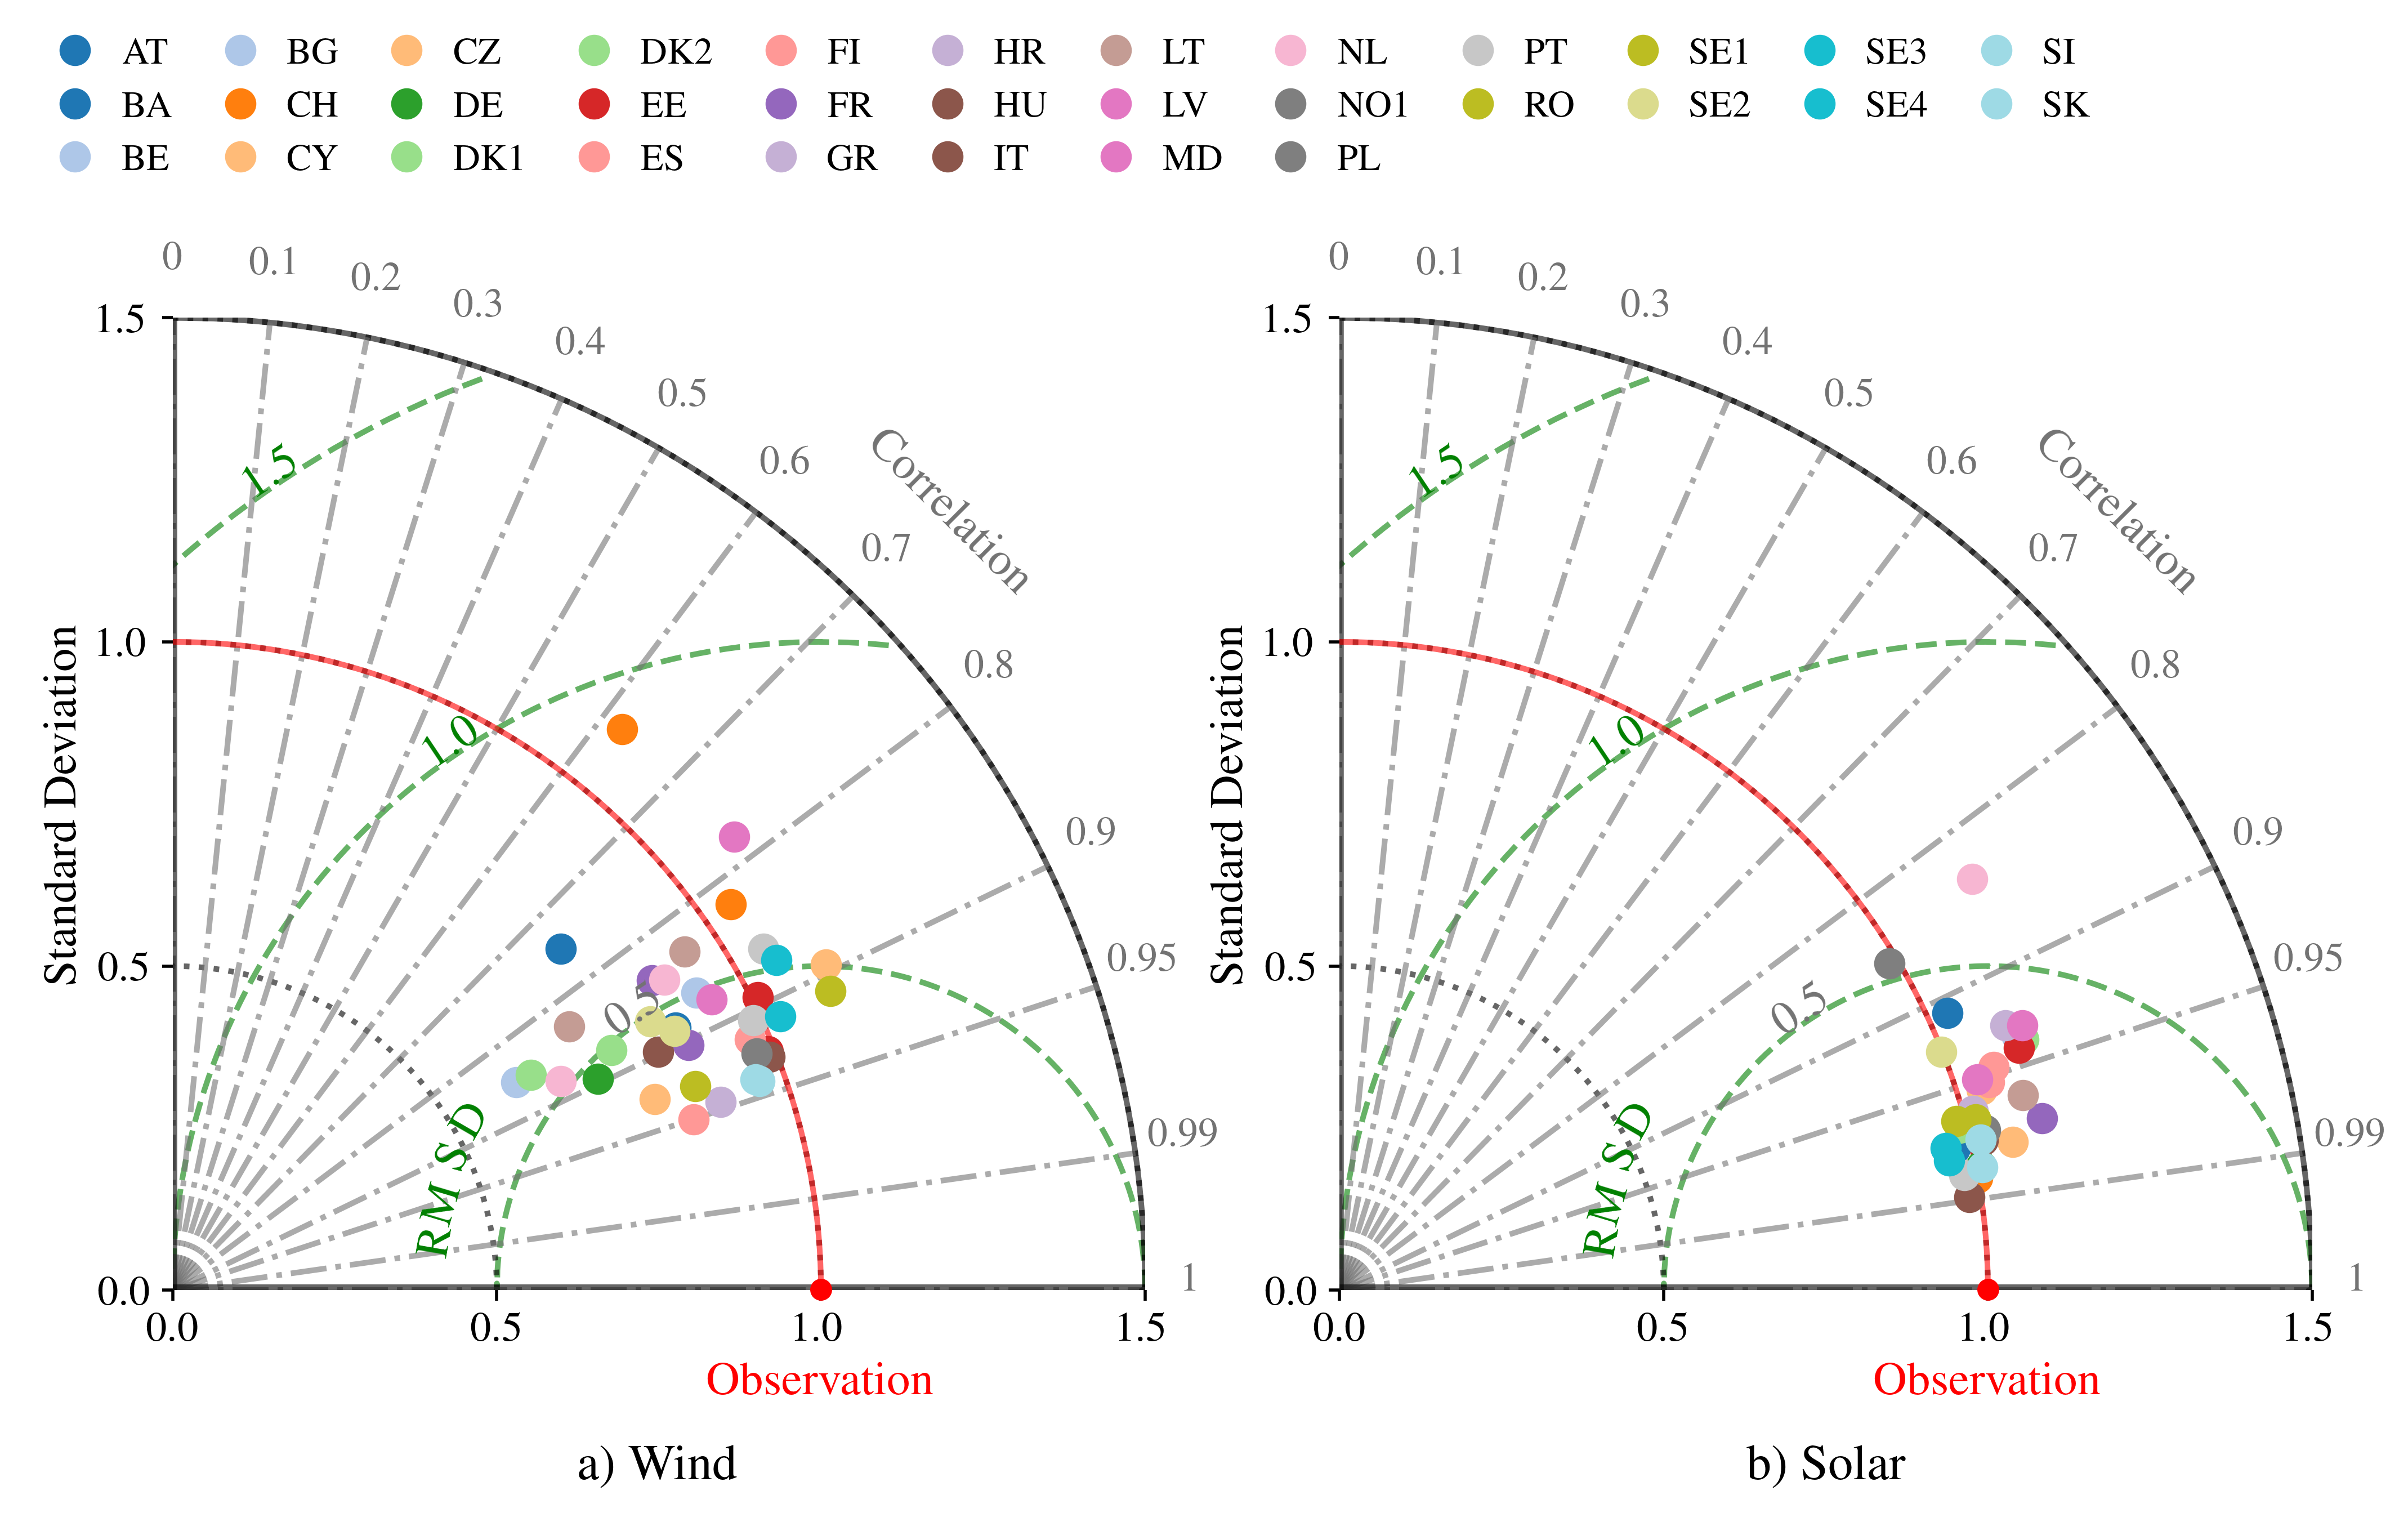

In [ ]:
if 'sm' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    def _to_code(lbl):
        if lbl == 'Reference':
            return 'Reference'
        if '(' in lbl and ')' in lbl:
            return lbl.split('(')[-1].split(')')[0].strip()
        return lbl

    def _style_corr(ax):
        blue_rgba = mcolors.to_rgba('b')
        for ln in ax.lines:
            if ln.get_linestyle() in [None, '', 'None']:
                continue
            ln.set_alpha(0.6)
            c = mcolors.to_rgba(ln.get_color())
            if np.allclose(c[:3], blue_rgba[:3], atol=0.08):
                ln.set_color((0.45, 0.45, 0.45, 0.9))

        for txt in ax.texts:
            t = txt.get_text()
            if 'Correlation Coefficient' in t:
                txt.set_text(t.replace('Correlation Coefficient', 'Correlation'))
                txt.set_color('0.45')
            elif t.strip() in ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.95', '0.99', '1']:
                txt.set_color('0.45')

    keep_idx = [
        i for i, lbl in enumerate(wind_taylor['label'])
        if (i == 0) or (lbl not in ['United Kingdom (UK)', 'UK', 'SE'])
    ]
    wind_taylor_plot = {
        'sdev': [wind_taylor['sdev'][i] for i in keep_idx],
        'crmsd': [wind_taylor['crmsd'][i] for i in keep_idx],
        'ccoef': [wind_taylor['ccoef'][i] for i in keep_idx],
        'label': [wind_taylor['label'][i] for i in keep_idx],
    }

    wind_labels_full = wind_taylor_plot['label'][1:]
    wind_labels_code = [_to_code(x) for x in wind_labels_full]
    wind_colors = [mcolors.to_hex(c) for c in plt.cm.tab20(np.linspace(0, 1, max(len(wind_labels_full), 1)))][:len(wind_labels_full)]
    wind_markers = {
        label_full: {'symbol': 'o', 'size': 8, 'faceColor': color, 'edgeColor': color, 'labelColor': 'black'}
        for label_full, color in zip(wind_labels_full, wind_colors)
    }

    sm.taylor_diagram(
        axes[0],
        np.array(wind_taylor_plot['sdev']),
        np.array(wind_taylor_plot['crmsd']),
        np.array(wind_taylor_plot['ccoef']),
        markerLegend='on',
        markerLabel=wind_taylor_plot['label'],
        markers=wind_markers,
        markerLayout=[None, 2],
        styleOBS='-',
        colOBS='r',
        markerobs='o',
        colRMS='g',
        tickRMS=[0.5, 1.0, 1.5],
        colCOR='0.45',
        colsCOR={'grid': '0.45', 'tick_labels': '0.45', 'title': '0.45'},
        titleCORshape='linear',
        titleOBS='Observation'
    )
    _style_corr(axes[0])

    wind_leg = axes[0].get_legend()
    if wind_leg is not None:
        wind_handles = wind_leg.legend_handles
        wind_labels = ['Reference'] + wind_labels_code
        wind_leg.remove()
    else:
        wind_handles, wind_labels = [], []

    pv_labels_full = pv_taylor['label'][1:]
    pv_labels_code = [_to_code(x) for x in pv_labels_full]
    pv_colors = [mcolors.to_hex(c) for c in plt.cm.tab20(np.linspace(0, 1, max(len(pv_labels_full), 1)))][:len(pv_labels_full)]
    pv_markers = {
        label_full: {'symbol': 'o', 'size': 8, 'faceColor': color, 'edgeColor': color, 'labelColor': 'black'}
        for label_full, color in zip(pv_labels_full, pv_colors)
    }

    sm.taylor_diagram(
        axes[1],
        np.array(pv_taylor['sdev']),
        np.array(pv_taylor['crmsd']),
        np.array(pv_taylor['ccoef']),
        markerLegend='on',
        markerLabel=pv_taylor['label'],
        markers=pv_markers,
        markerLayout=[None, 2],
        styleOBS='-',
        colOBS='r',
        markerobs='o',
        colRMS='g',
        tickRMS=[0.5, 1.0, 1.5],
        colCOR='0.45',
        colsCOR={'grid': '0.45', 'tick_labels': '0.45', 'title': '0.45'},
        titleCORshape='linear',
        titleOBS='Observation'
    )
    _style_corr(axes[1])

    pv_leg = axes[1].get_legend()
    if pv_leg is not None:
        pv_handles = pv_leg.legend_handles
        pv_labels = pv_labels_code
        pv_leg.remove()
    else:
        pv_handles, pv_labels = [], []

    left_margin = 0.09

    if wind_labels:
        axes[0].legend(
            wind_handles, wind_labels,
            loc='lower left',
            bbox_to_anchor=(left_margin, 0.98),
            bbox_transform=fig.transFigure,
            ncol=12,
            frameon=False,
            fontsize=12,
            alignment='left',
            handletextpad=0.25,  
            columnspacing=0.8
        )

    if pv_labels:
        axes[1].legend(
            pv_handles, pv_labels,
            loc='lower left',
            bbox_to_anchor=(left_margin, 0.83),
            bbox_transform=fig.transFigure,
            ncol=12,
            frameon=False,
            fontsize=12,
            alignment='left',
            handletextpad=0.25,  
            columnspacing=0.8
        )

    axes[0].text(0.5, -0.16, 'a) Wind', transform=axes[0].transAxes, ha='center', va='top', fontsize=16)
    axes[1].text(0.5, -0.16, 'b) Solar', transform=axes[1].transAxes, ha='center', va='top', fontsize=16)

    out = OUT_DIR / f'taylor_diagram_wind_solar_combined_{YEAR}.pdf'
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
else:
    print("SkillMetrics package not available. Skipping combined subfigure.")
